In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew
from scipy.stats import kurtosis

from IPython.display import display
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

In [3]:
train = pd.read_csv("train_data.csv")
test = pd.read_csv("test_data.csv")
sample = pd.read_csv("sample_submission.csv")

In [4]:
print("="*60)
print("TRAIN SHAPE")
print(train.shape)

print("="*60)
print("TEST SHAPE")
print(test.shape)

print("="*60)
display(train.head())

print("="*60)
display(test.head())

TRAIN SHAPE
(3200, 23)
TEST SHAPE
(3200, 22)


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,target
0,1,0.3800,0.0160,0,0,0,0,0,0,0.1080,0.0009,0,0,0,0.1270,0,1,0,0,0,0.0850,0,class3
1,2,0.3700,0.0250,0,0,0,0,0,0,0.0840,0.0051,0,0,0,0.0800,0,0,0,0,0,0.1040,0,class3
2,3,0.5700,0.0220,0,0,0,0,0,0,0.1112,0.0019,0,0,0,0.1121,0,0,0,0,0,0.0990,0,class3
3,4,0.5400,0.0206,0,1,0,0,0,0,0.1010,0.0002,0,1,0,0.1580,0,0,0,0,0,0.0640,0,class3
4,5,0.4200,0.0208,0,0,0,0,0,0,0.1230,0.0072,0,0,0,0.1040,0,0,0,0,0,0.1160,0,class2


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
0,10000,0.5700,0.0230,0,1,0,0,0,0,0.1150,0.0060,0,1,1,0.1195,0,0,0,0,0,0.0960,0
1,10001,0.5400,0.0130,1,0,0,0,0,0,0.1020,0.0008,0,0,0,0.1130,0,0,0,0,0,0.0910,0
2,10002,0.5600,0.0190,0,1,0,0,0,0,0.0960,0.0010,0,0,0,0.1030,0,0,0,0,0,0.0930,0
3,10003,0.2600,0.0230,1,0,0,0,0,0,0.0960,0.0011,0,0,0,0.1230,0,0,0,0,0,0.0780,0
4,10004,0.6000,0.0230,0,1,1,0,0,0,0.1550,0.0000,0,1,0,0.2210,0,0,0,1,0,0.0700,0


In [5]:
train.info()

print()

test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3200 entries, 0 to 3199
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      3200 non-null   int64  
 1   f1      3200 non-null   float64
 2   f2      3200 non-null   float64
 3   f3      3200 non-null   int64  
 4   f4      3200 non-null   int64  
 5   f5      3200 non-null   int64  
 6   f6      3200 non-null   int64  
 7   f7      3200 non-null   int64  
 8   f8      3200 non-null   int64  
 9   f9      3200 non-null   float64
 10  f10     3200 non-null   float64
 11  f11     3200 non-null   int64  
 12  f12     3200 non-null   int64  
 13  f13     3200 non-null   int64  
 14  f14     3200 non-null   float64
 15  f15     3200 non-null   int64  
 16  f16     3200 non-null   int64  
 17  f17     3200 non-null   int64  
 18  f18     3200 non-null   int64  
 19  f19     3200 non-null   int64  
 20  f20     3200 non-null   float64
 21  f21     3200 non-null   int64  
 22  

In [6]:
train.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,3200.0000,NaN,NaN,NaN,1600.5000,923.9048,1.0000,800.7500,1600.5000,2400.2500,3200.0000
f1,3200.0000,NaN,NaN,NaN,0.5169,0.1898,0.0100,0.3600,0.5400,0.6700,0.9400
f2,3200.0000,NaN,NaN,NaN,0.0201,0.0075,0.0005,0.0170,0.0206,0.0230,0.1059
f3,3200.0000,NaN,NaN,NaN,0.0450,0.2073,0.0000,0.0000,0.0000,0.0000,1.0000
f4,3200.0000,NaN,NaN,NaN,0.3013,0.4589,0.0000,0.0000,0.0000,1.0000,1.0000
f5,3200.0000,NaN,NaN,NaN,0.0147,0.1203,0.0000,0.0000,0.0000,0.0000,1.0000
f6,3200.0000,NaN,NaN,NaN,0.0387,0.1930,0.0000,0.0000,0.0000,0.0000,1.0000
f7,3200.0000,NaN,NaN,NaN,0.0050,0.0705,0.0000,0.0000,0.0000,0.0000,1.0000
f8,3200.0000,NaN,NaN,NaN,0.0122,0.1097,0.0000,0.0000,0.0000,0.0000,1.0000
f9,3200.0000,NaN,NaN,NaN,0.1080,0.0352,0.0020,0.0880,0.1050,0.1220,0.4300


In [7]:
print(train.columns.tolist())

['ID', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'target']


In [8]:
print("missing values in train data:")
missing = pd.DataFrame({
    "Missing": train.isnull().sum(),
    "Percent": train.isnull().mean()*100
})

missing = missing.sort_values("Missing", ascending=False)

display(missing)

print("missing values in test data:")

missing_test = pd.DataFrame({
    "Missing": test.isnull().sum(),
    "Percent": test.isnull().mean()*100
})

display(missing_test)

missing values in train data:


,Missing,Percent
ID,0,0.0000
f1,0,0.0000
f2,0,0.0000
f3,0,0.0000
f4,0,0.0000
f5,0,0.0000
f6,0,0.0000
f7,0,0.0000
f8,0,0.0000
f9,0,0.0000


missing values in test data:


,Missing,Percent
ID,0,0.0000
f1,0,0.0000
f2,0,0.0000
f3,0,0.0000
f4,0,0.0000
f5,0,0.0000
f6,0,0.0000
f7,0,0.0000
f8,0,0.0000
f9,0,0.0000


In [9]:
print("Duplicated rows in train:", train.duplicated().sum())

Duplicated rows in train: 0


In [10]:
print(train["ID"].duplicated().sum())
print(test["ID"].duplicated().sum())

0
0


In [11]:
target_counts = train["target"].value_counts()

display(target_counts)

target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

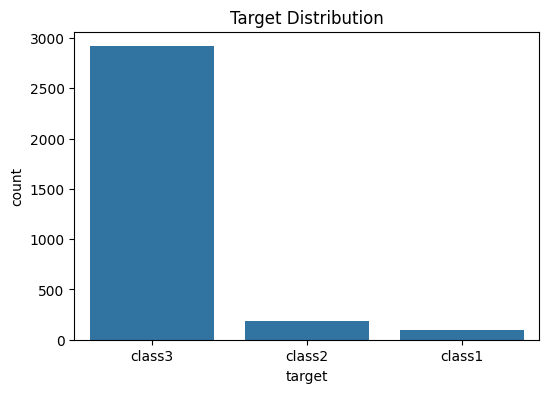

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="target",
    order=target_counts.index
)

plt.title("Target Distribution")

plt.show()

In [13]:
target_percent = (
    train["target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(target_percent)

target
class3   91.1200
class2    5.9700
class1    2.9100
Name: proportion, dtype: float64

In [14]:
ignore = ["ID","target"]

features = [c for c in train.columns if c not in ignore]

num_cols = train[features].select_dtypes(include=np.number).columns.tolist()

cat_cols = train[features].select_dtypes(exclude=np.number).columns.tolist()

print("Numerical:",len(num_cols))
print(num_cols)

print()

print("Categorical:",len(cat_cols))
print(cat_cols)

Numerical: 21
['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21']

Categorical: 0
[]


In [15]:
ID_COL = "ID"
TARGET_COL = "target"

features = [c for c in train.columns if c not in [ID_COL, TARGET_COL]]

print("Number of features:", len(features))
print("Features:", features)

print("\nMissing values in train:", train[features + [TARGET_COL]].isna().sum().sum())
print("Missing values in test:", test[features].isna().sum().sum())

print("\nTarget distribution:")
display(train[TARGET_COL].value_counts())
display(train[TARGET_COL].value_counts(normalize=True))

Number of features: 21
Features: ['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21']

Missing values in train: 0
Missing values in test: 0

Target distribution:


target
class3    2916
class2     191
class1      93
Name: count, dtype: int64

target
class3   0.9113
class2   0.0597
class1   0.0291
Name: proportion, dtype: float64

In [16]:
unique_df = pd.DataFrame({
    "Unique Values":train[features].nunique(),
    "Data Type":train[features].dtypes
})

unique_df.sort_values("Unique Values")

,Unique Values,Data Type
f4,2,int64
f3,2,int64
f6,2,int64
f5,2,int64
f7,2,int64
f8,2,int64
f11,2,int64
f12,2,int64
f16,2,int64
f13,2,int64


# Histogram

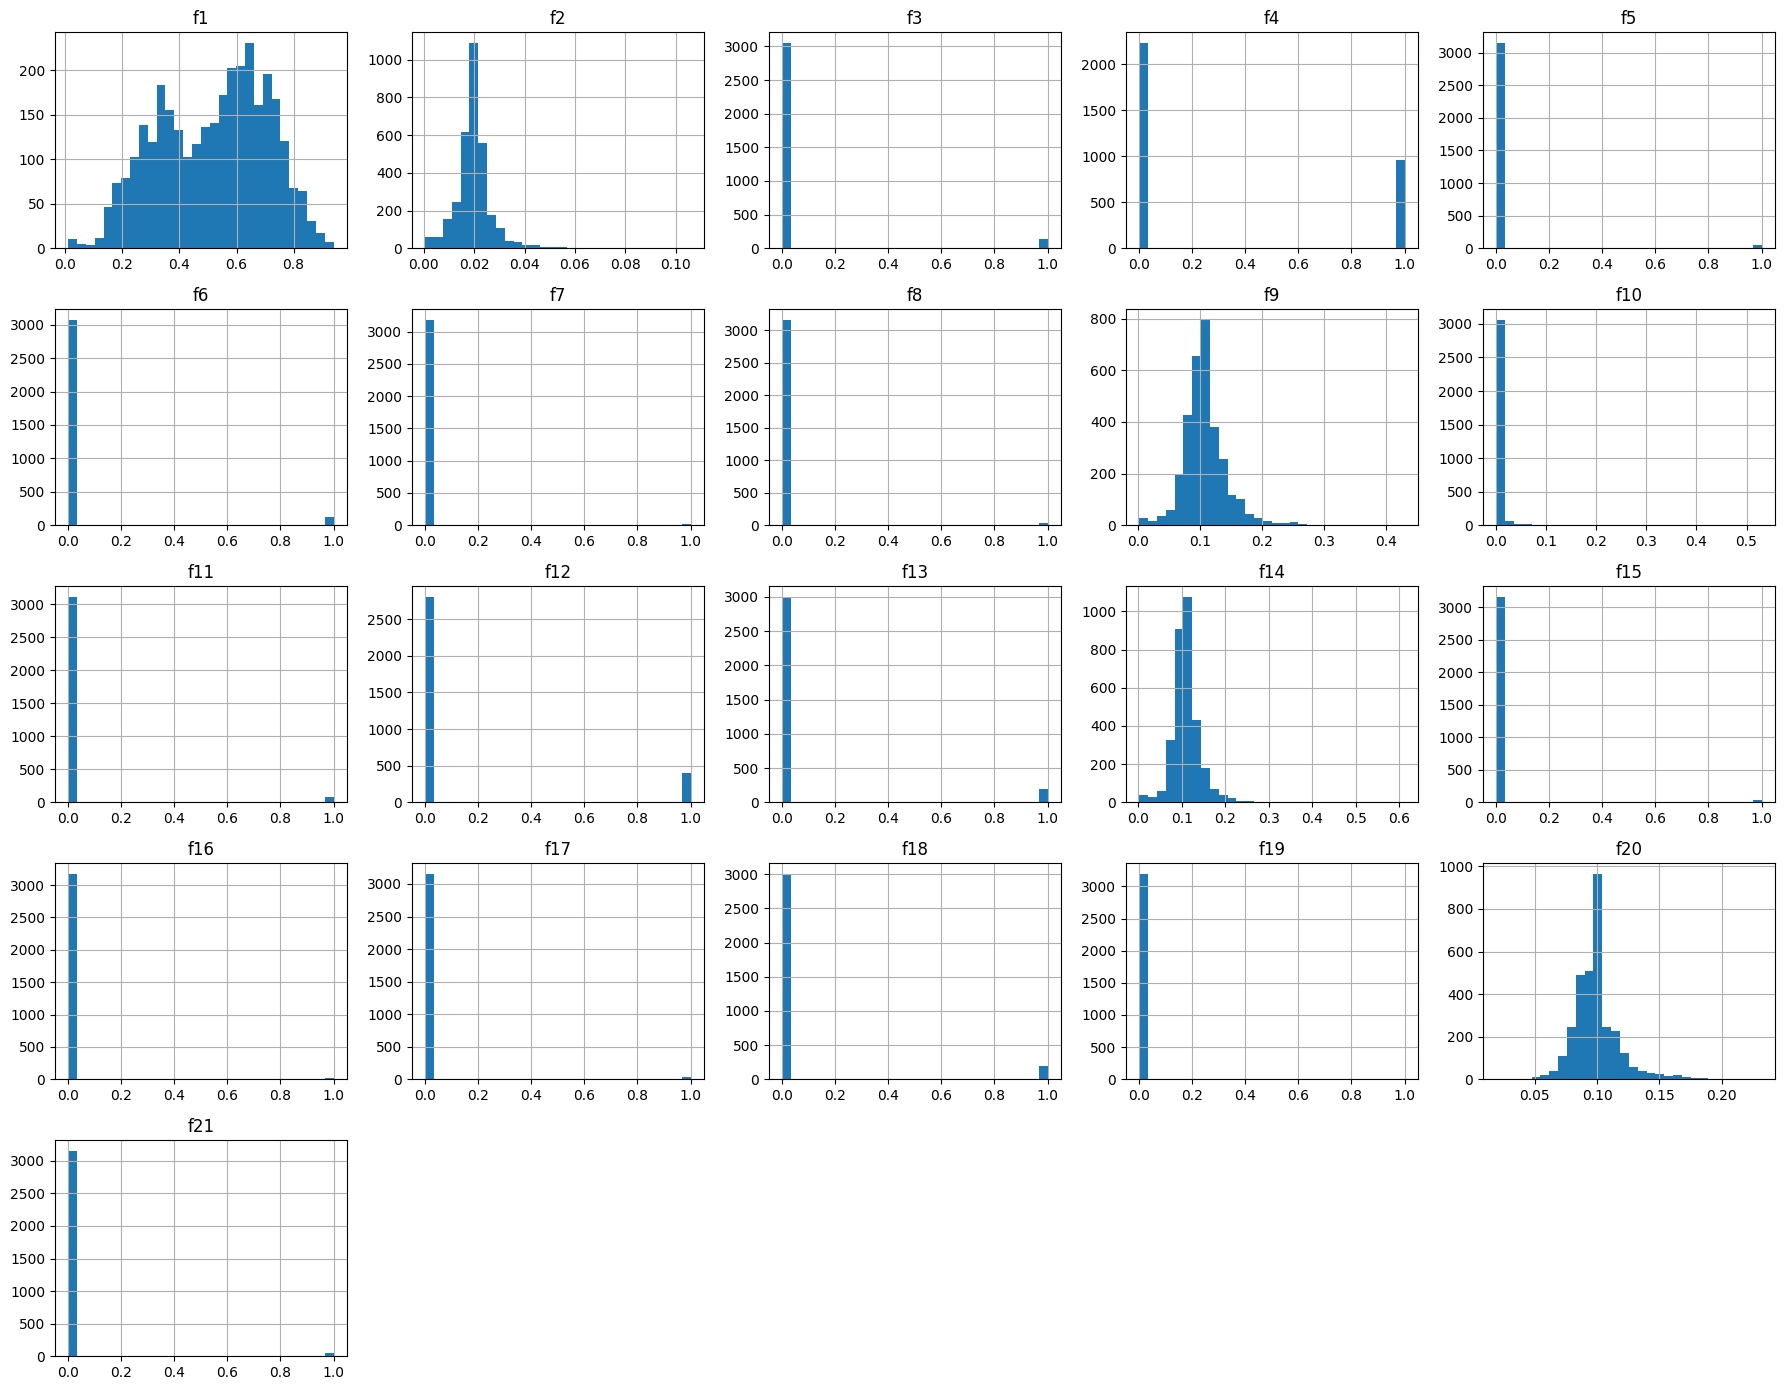

In [17]:
train[num_cols].hist(
    figsize=(18,14),
    bins=30
)

plt.tight_layout()
plt.show()

# Boxplots

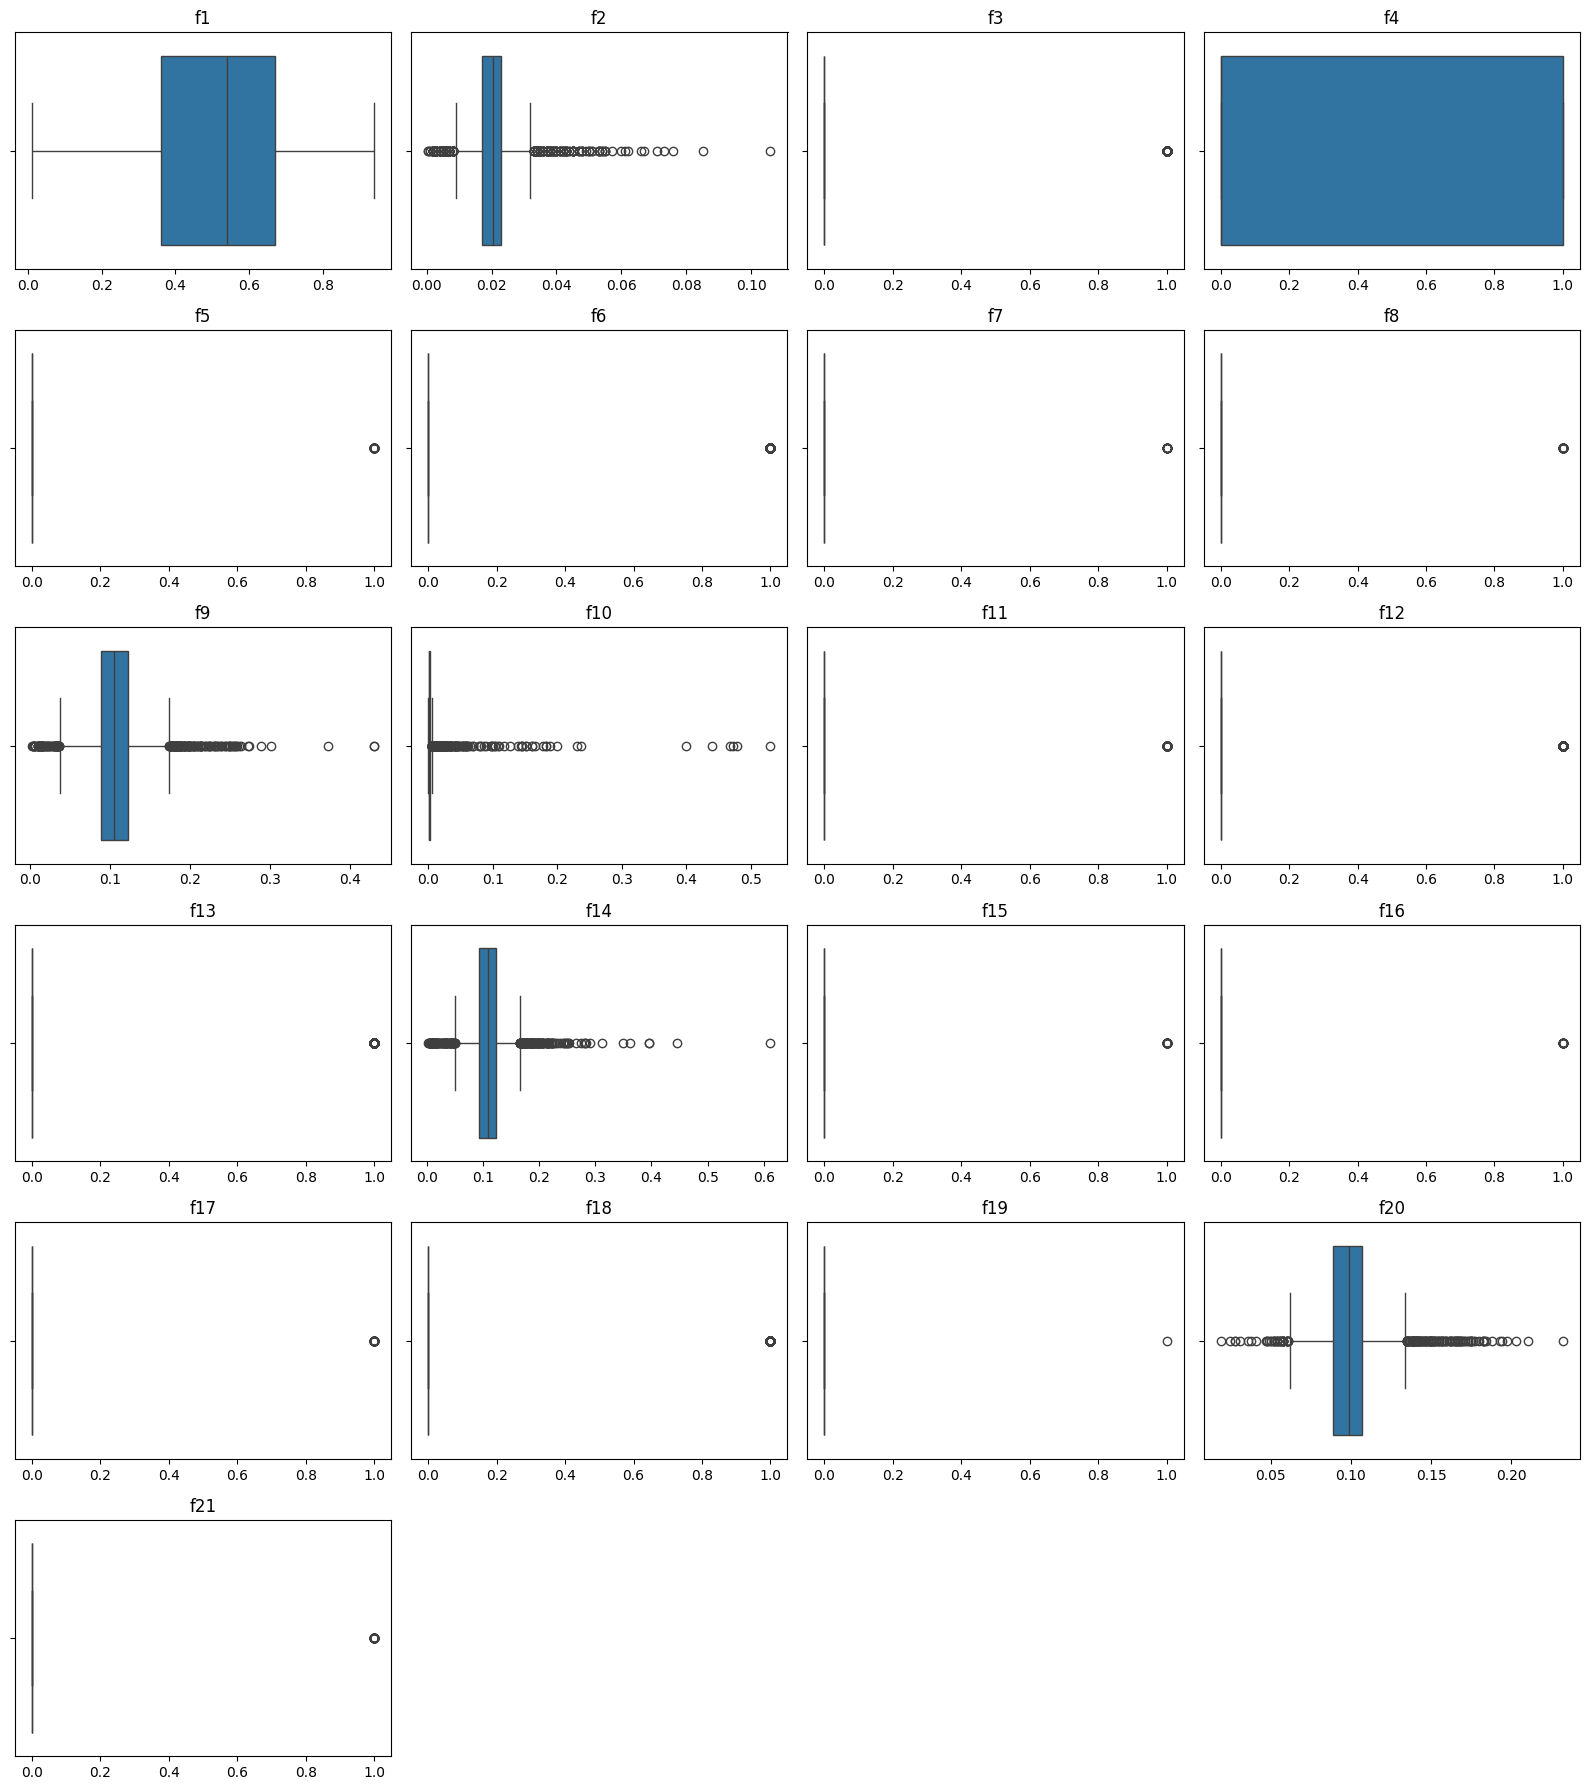

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 4                         
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train[col],
        ax=axes[i]
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("")


for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Skewness

In [19]:
skew_df = pd.DataFrame({
    "Skewness":train[num_cols].apply(skew),
    "Kurtosis":train[num_cols].apply(kurtosis)
})

skew_df.sort_values("Skewness")

,Skewness,Kurtosis
f1,-0.2145,-0.8893
f4,0.8664,-1.2494
f20,1.2184,5.0421
f9,1.3434,7.7222
f2,1.9297,13.2332
f12,2.2984,3.2825
f14,2.3889,23.8203
f13,3.6370,11.2276
f18,3.7290,11.9052
f3,4.3897,17.2693


# Correlation

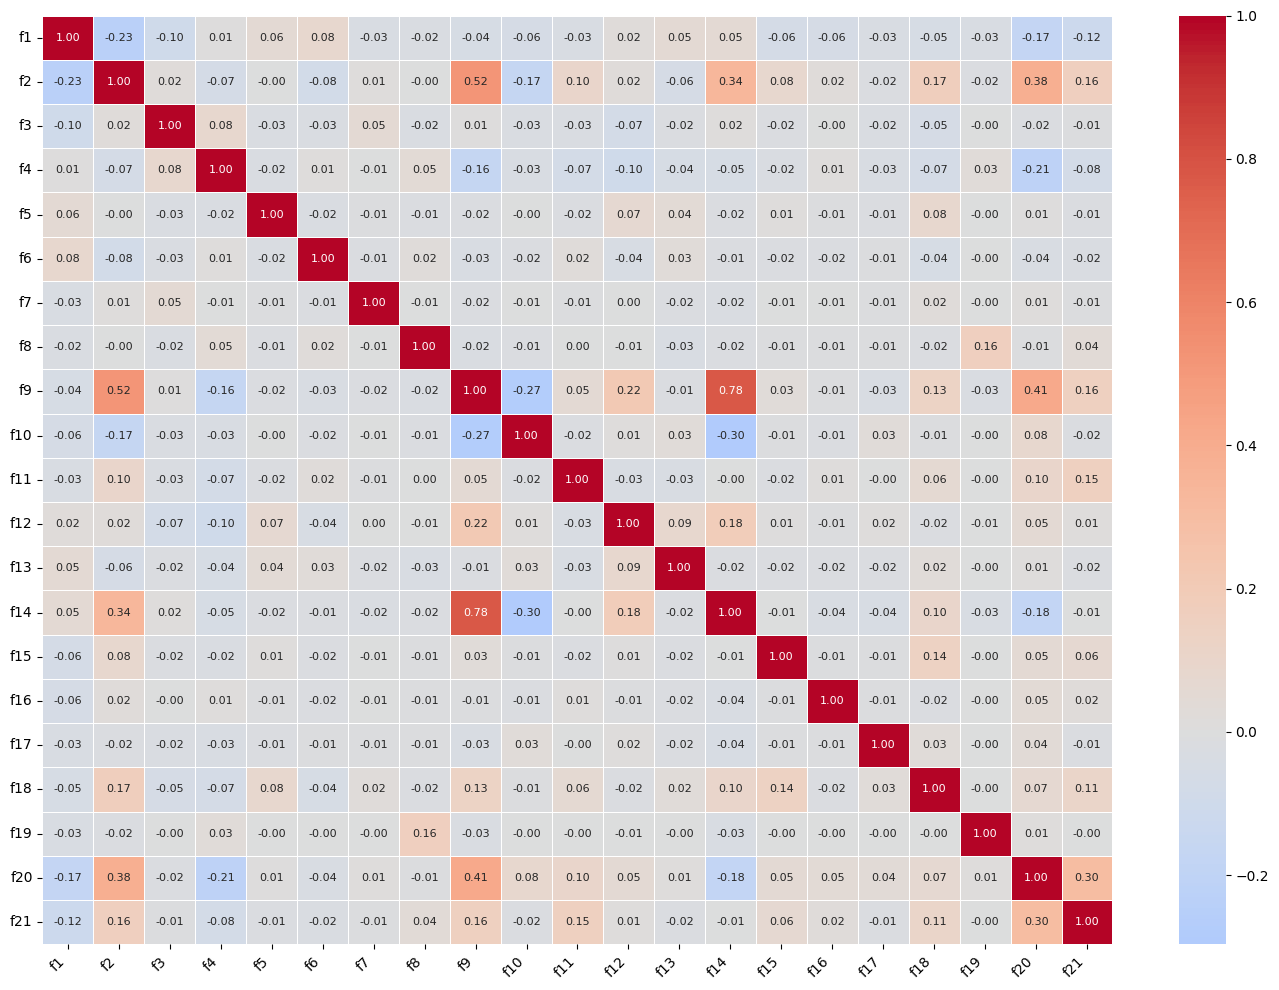

In [20]:
corr = train[num_cols].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    annot_kws={"size":8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# الخطوة الحالية: تحليل أهمية الميزات (Feature Importance Analysis)

# 1. ANOVA F-score

In [21]:
from sklearn.feature_selection import f_classif

X = train.drop(columns=["ID", "target"])
y = train["target"]

f_scores, p_values = f_classif(X, y)

anova_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "F-Score": f_scores,
        "P-Value": p_values
    })
    .sort_values("F-Score", ascending=False)
)

display(anova_df)

,Feature,F-Score,P-Value
9,f10,991.7618,0.0000
13,f14,331.4847,0.0000
8,f9,283.3635,0.0000
1,f2,117.5129,0.0000
11,f12,14.8522,0.0000
12,f13,14.2893,0.0000
3,f4,4.3133,0.0135
19,f20,3.0825,0.0460
5,f6,2.7869,0.0618
2,f3,2.3050,0.0999


# 2. Mutual Information

In [22]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = (
    pd.DataFrame({
        "Feature": X.columns,
        "Mutual Information": mi
    })
    .sort_values("Mutual Information", ascending=False)
)

display(mi_df)

,Feature,Mutual Information
9,f10,0.2818
13,f14,0.1380
8,f9,0.1082
1,f2,0.0921
11,f12,0.0206
12,f13,0.0127
0,f1,0.0122
16,f17,0.0096
19,f20,0.0095
15,f16,0.0042


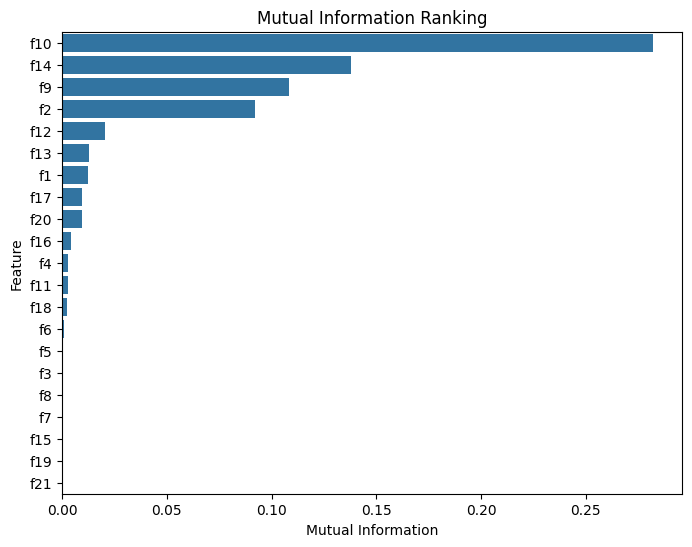

In [23]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=mi_df,
    x="Mutual Information",
    y="Feature"
)

plt.title("Mutual Information Ranking")
plt.show()

#  سنرسم:

بالنسبة للميزات المستمرة (f1, f2, f9, f10, f14, f20):

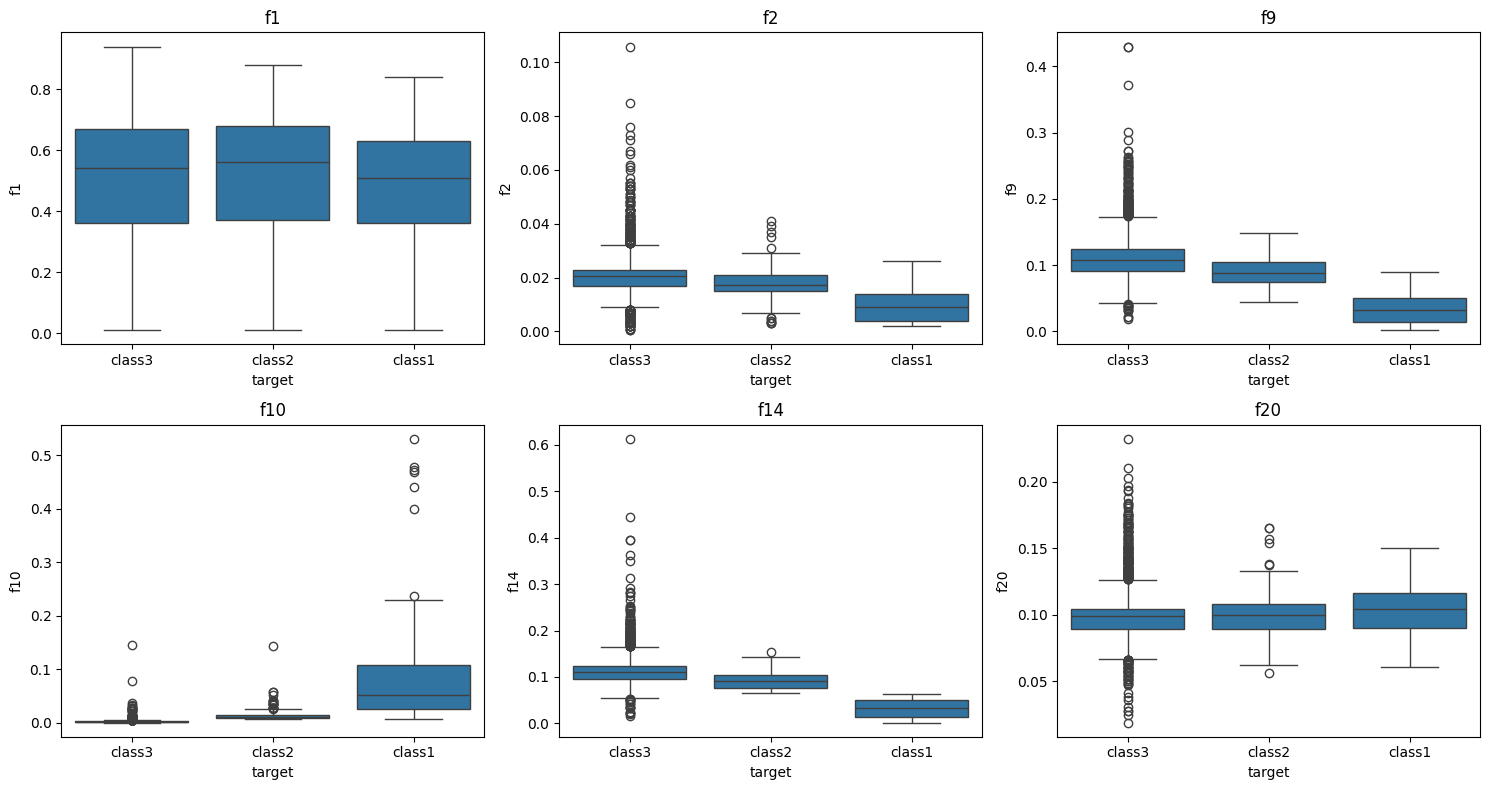

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

continuous_cols = ["f1","f2","f9","f10","f14","f20"]

n_cols = 3  # عدد الأعمدة في الشبكة
n_rows = math.ceil(len(continuous_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(
        data=train,
        x="target",
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(col)

# حذف المحاور الفارغة إذا وجدت
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

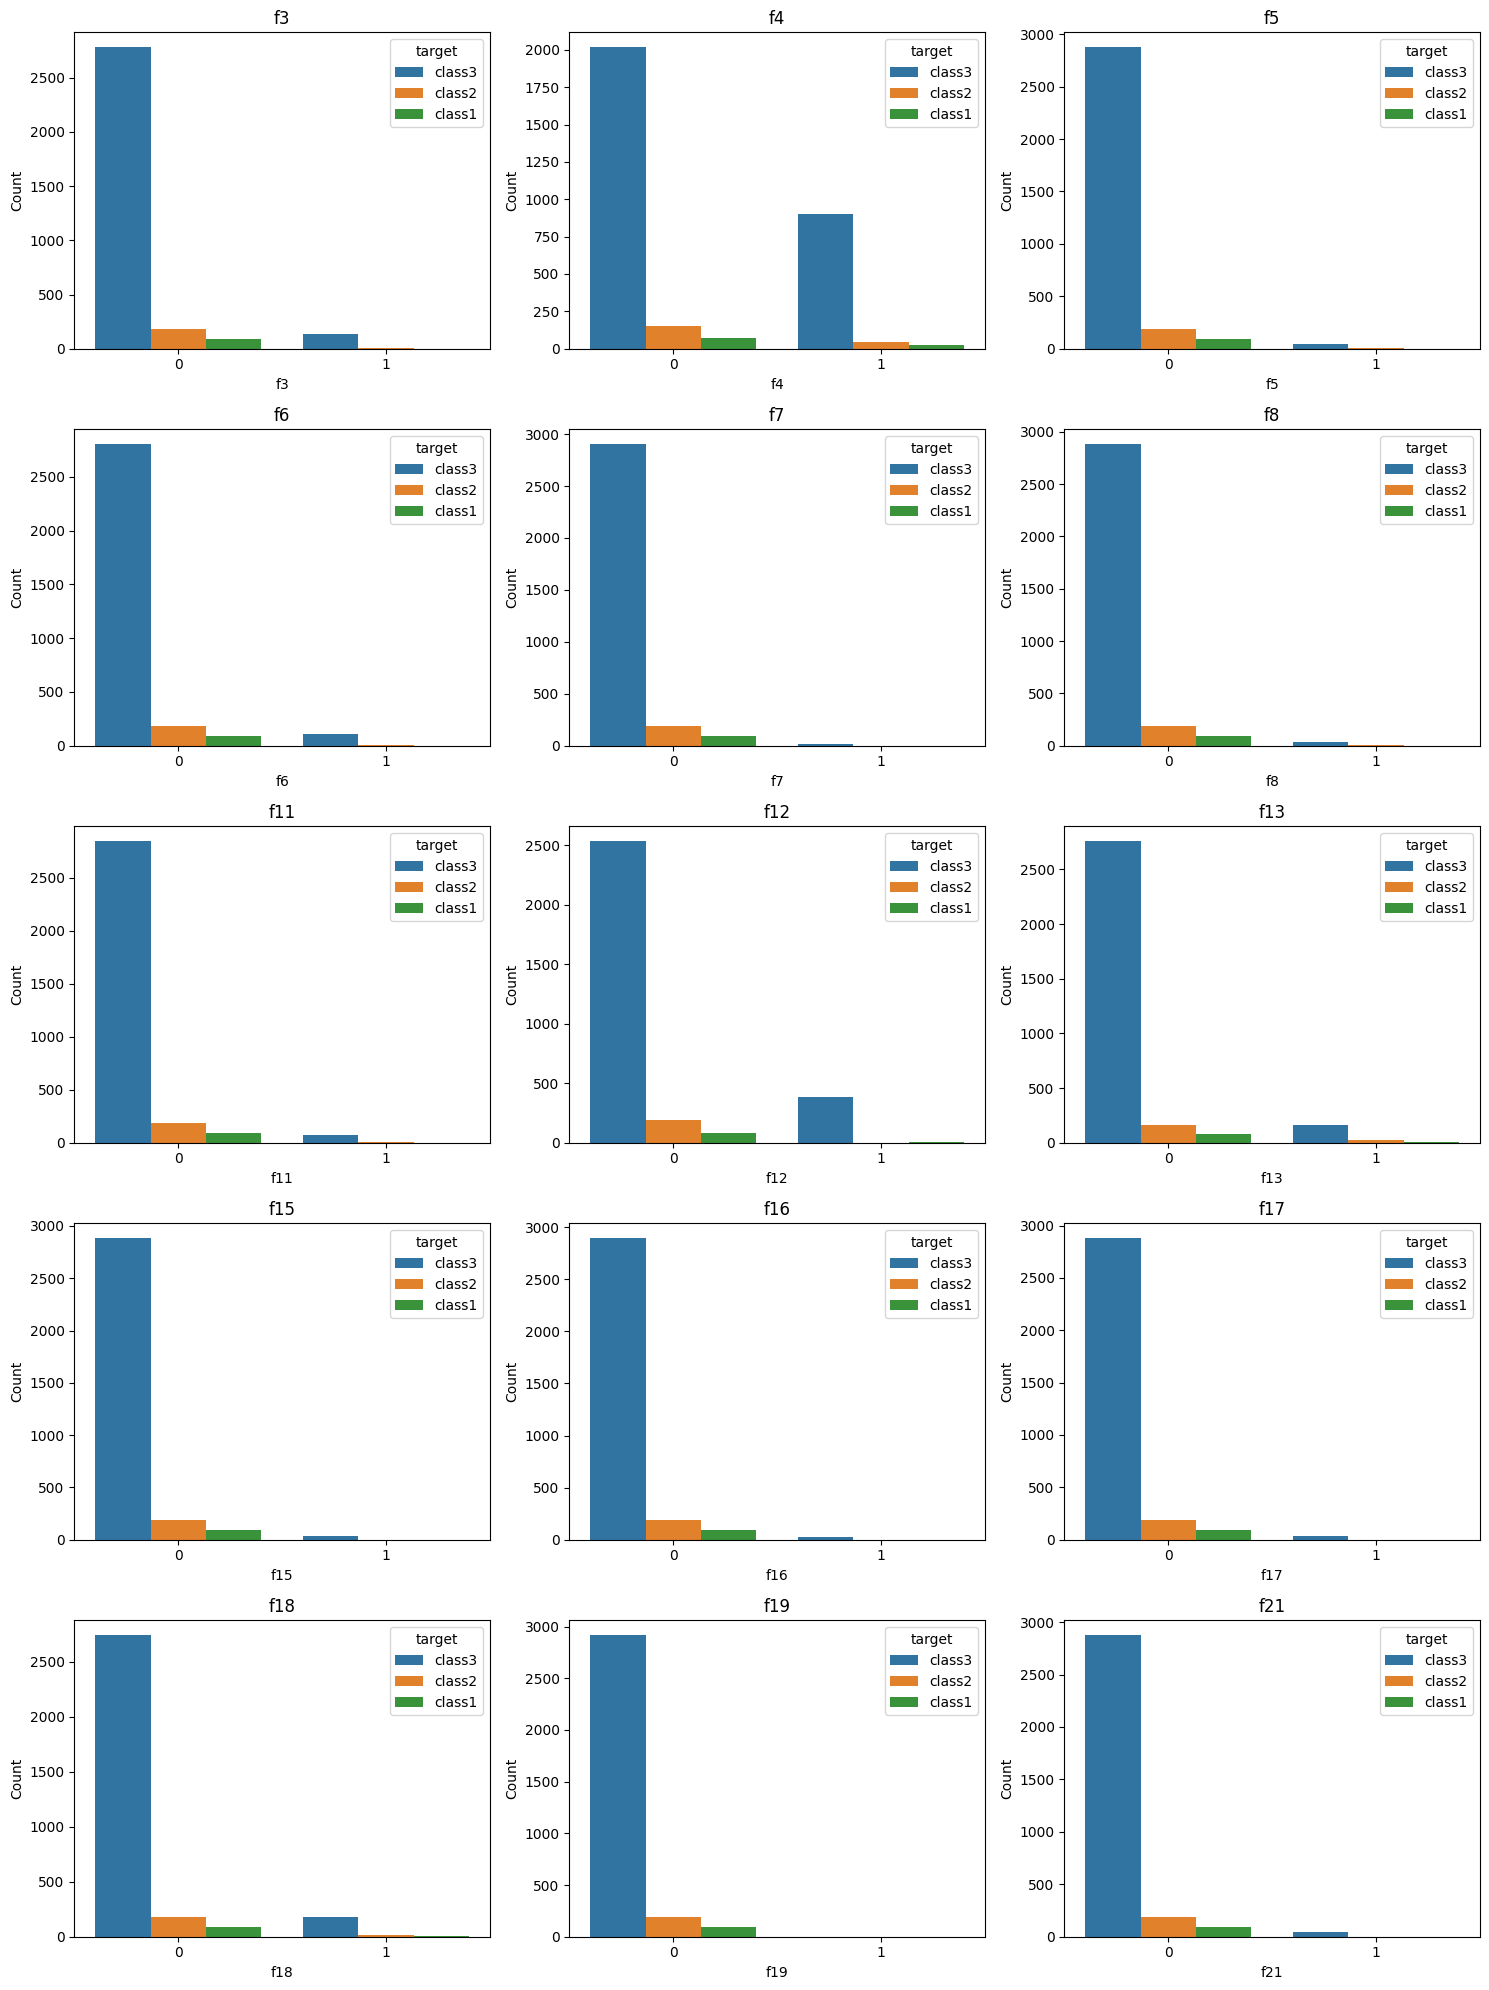

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

binary_cols = [
    "f3","f4","f5","f6","f7","f8",
    "f11","f12","f13","f15",
    "f16","f17","f18","f19","f21"
]

n_cols = 3  # عدد الأعمدة في الشبكة
n_rows = math.ceil(len(binary_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(
        data=train,
        x=col,
        hue="target",
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

# حذف المحاور الفارغة
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# هون رح نحط التجارب التي عملنا عليها وفي النهاية سوف نضع النتيجة النهائية التي اخترناها وفي نهاية النوت بوك سوف يكون ال MLFlow

## Evaluation Protocol

استخدمنا **Stratified 5-Fold Cross Validation** كإستراتيجية التحقق المحلية الرئيسية (**local validation strategy**) نظرا لأن توزيع الهدف غير متوازن (**target distribution is imbalanced**) ومقياس التقييم في المسابقة هو **Macro-F1**. 

لكل نموذج، قمنا بتتبع:
* نتائج **Macro-F1 scores** لكل جزء (**fold**).
* المتوسط الحسابي (**mean**).
* الانحراف المعياري (**standard deviation**).
* نتائج **OOF Macro-F1**
وقد تم استخدام نتائج لوحة الصدارة العامة (**Public leaderboard scores**) فقط كفحص خارجي للتعميم 

In [45]:
from sklearn.preprocessing import LabelEncoder

X = train.drop(columns=["ID", "target"])
y = train["target"]

X_test = test.drop(columns=["ID"])

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y = le.fit_transform(train["target"])
print(le.classes_)

['class1' 'class2' 'class3']


# XgBoost BaseLine Final Selected

In [46]:
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import pandas as pd

In [47]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

In [48]:
oof_pred = np.zeros(len(X), dtype=int)

test_pred_prob = np.zeros(
    (len(X_test), len(le.classes_))
)

fold_scores = []

In [49]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_encoded),1):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    model = XGBClassifier(

        objective="multi:softprob",

        num_class=3,

        n_estimators=500,

        learning_rate=0.05,

        max_depth=6,

        subsample=0.8,

        colsample_bytree=0.8,

        min_child_weight=1,

        reg_alpha=0,

        reg_lambda=1,

        random_state=42,

        tree_method="hist",

        eval_metric="mlogloss"

    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_valid)

    oof_pred[valid_idx] = pred

    score = f1_score(
        y_valid,
        pred,
        average="macro"
    )

    fold_scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

    test_pred_prob += (
        model.predict_proba(X_test)/N_SPLITS
    )


Fold 1: 0.97692
Fold 2: 0.98216
Fold 3: 0.99538
Fold 4: 0.96752
Fold 5: 0.97368


In [50]:
print("="*50)
print("CV Macro F1")
print(np.mean(fold_scores))

CV Macro F1
0.9791321694347029


In [51]:
print(
    classification_report(
        y_encoded,
        oof_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      class1       0.97      0.98      0.97        93
      class2       0.96      0.97      0.97       191
      class3       1.00      1.00      1.00      2916

    accuracy                           1.00      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       1.00      1.00      1.00      3200



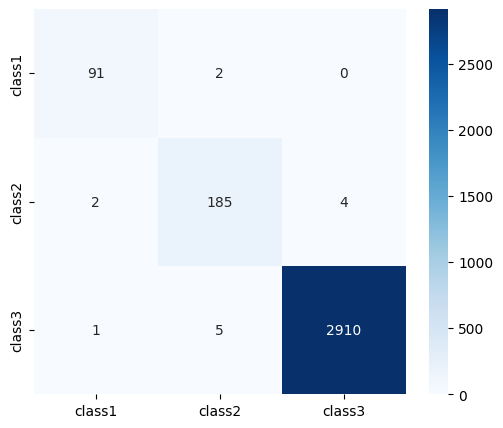

In [52]:
cm = confusion_matrix(
    y_encoded,
    oof_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.show()

In [53]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
9,f10,0.3589
11,f12,0.2182
13,f14,0.1169
16,f17,0.0637
8,f9,0.0421
12,f13,0.0321
1,f2,0.0266
3,f4,0.0262
10,f11,0.0221
5,f6,0.0171


In [54]:
test_pred = np.argmax(
    test_pred_prob,
    axis=1
)

submission = pd.DataFrame({

    "ID":test["ID"],

    "target":le.inverse_transform(test_pred)

})

submission.to_csv(
    "BaseLine_Submoission.csv",
    index=False
)

## 1- CatBoost

In [204]:
from sklearn.model_selection import StratifiedKFold

N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

In [205]:
from catboost import CatBoostClassifier

from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np

In [206]:
oof_pred = np.zeros(len(X), dtype=int)

test_pred_prob = np.zeros(
    (len(X_test), len(le.classes_))
)

fold_scores = []

In [207]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_encoded), 1):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="MultiClass",
        eval_metric="TotalF1",
        random_seed=42,
        verbose=False
    )

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        use_best_model=True
    )

    pred = model.predict(X_valid).astype(int).flatten()

    oof_pred[valid_idx] = pred

    score = f1_score(
        y_valid,
        pred,
        average="macro"
    )

    fold_scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

    test_pred_prob += (
        model.predict_proba(X_test) / N_SPLITS
    )

Fold 1: 0.99539
Fold 2: 0.98259
Fold 3: 1.00000
Fold 4: 0.98205
Fold 5: 1.00000


In [208]:
print("=" * 50)

print("CV Macro F1")

print(np.mean(fold_scores))

print("=" * 50)

CV Macro F1
0.9920047782281072


In [209]:
print(
    classification_report(
        y_encoded,
        oof_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      class1       0.99      1.00      0.99        93
      class2       0.96      1.00      0.98       191
      class3       1.00      1.00      1.00      2916

    accuracy                           1.00      3200
   macro avg       0.98      1.00      0.99      3200
weighted avg       1.00      1.00      1.00      3200



# Confusion Matrix

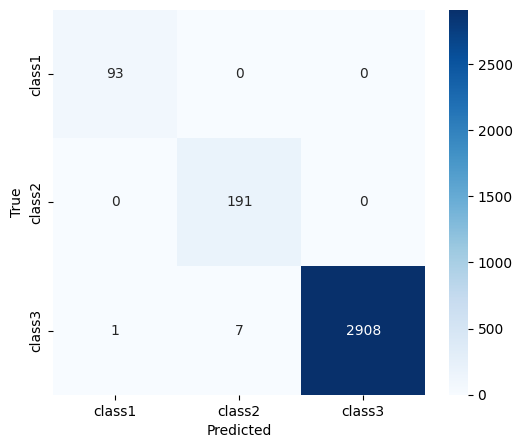

In [210]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_encoded, oof_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()

# Feature Importance

In [211]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
9,f10,61.2310
13,f14,13.8168
11,f12,8.1391
8,f9,4.9307
1,f2,4.8341
0,f1,2.3790
16,f17,1.7922
19,f20,1.7833
12,f13,0.3569
14,f15,0.1181


# Validation Audit

In [212]:
display(train.drop(columns=["target"]).describe())
display(test.describe())

,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
count,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000
mean,1600.5000,0.5169,0.0201,0.0450,0.3013,0.0147,0.0387,0.0050,0.0122,0.1080,0.0052,0.0253,0.1228,0.0619,0.1099,0.0112,0.0075,0.0128,0.0594,0.0003,0.0992,0.0134
std,923.9048,0.1898,0.0075,0.2073,0.4589,0.1203,0.1930,0.0705,0.1097,0.0352,0.0251,0.1571,0.3283,0.2410,0.0343,0.1055,0.0863,0.1125,0.2364,0.0177,0.0185,0.1152
min,1.0000,0.0100,0.0005,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0020,0.0000,0.0000,0.0000,0.0000,0.0020,0.0000,0.0000,0.0000,0.0000,0.0000,0.0190,0.0000
25%,800.7500,0.3600,0.0170,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0880,0.0005,0.0000,0.0000,0.0000,0.0930,0.0000,0.0000,0.0000,0.0000,0.0000,0.0890,0.0000
50%,1600.5000,0.5400,0.0206,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1050,0.0016,0.0000,0.0000,0.0000,0.1080,0.0000,0.0000,0.0000,0.0000,0.0000,0.0990,0.0000
75%,2400.2500,0.6700,0.0230,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.1220,0.0024,0.0000,0.0000,0.0000,0.1220,0.0000,0.0000,0.0000,0.0000,0.0000,0.1070,0.0000
max,3200.0000,0.9400,0.1059,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.4300,0.5300,1.0000,1.0000,1.0000,0.6120,1.0000,1.0000,1.0000,1.0000,1.0000,0.2320,1.0000


,ID,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21
count,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000,3200.0000
mean,11599.5000,0.5268,0.0197,0.0466,0.3025,0.0191,0.0372,0.0209,0.0184,0.1110,0.0051,0.0269,0.1394,0.0697,0.1167,0.0141,0.0072,0.0125,0.0772,0.0000,0.0964,0.0075
std,923.9048,0.1889,0.0078,0.2107,0.4594,0.1368,0.1893,0.1432,0.1345,0.0377,0.0234,0.1617,0.3464,0.2547,0.0388,0.1178,0.0845,0.1111,0.2669,0.0000,0.0194,0.0863
min,10000.0000,0.0100,0.0005,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0025,0.0000,0.0000,0.0000,0.0000,0.0024,0.0000,0.0000,0.0000,0.0000,0.0000,0.0170,0.0000
25%,10799.7500,0.3800,0.0170,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0900,0.0009,0.0000,0.0000,0.0000,0.0970,0.0000,0.0000,0.0000,0.0000,0.0000,0.0860,0.0000
50%,11599.5000,0.5500,0.0201,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1080,0.0018,0.0000,0.0000,0.0000,0.1140,0.0000,0.0000,0.0000,0.0000,0.0000,0.0960,0.0000
75%,12399.2500,0.6800,0.0208,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.1290,0.0029,0.0000,0.0000,0.0000,0.1320,0.0000,0.0000,0.0000,0.0000,0.0000,0.1040,0.0000
max,13199.0000,0.9700,0.1800,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.6000,0.5000,1.0000,1.0000,1.0000,0.6420,1.0000,1.0000,1.0000,1.0000,0.0000,0.2330,1.0000


In [213]:
comparison = pd.DataFrame({
    "Train Mean": X.mean(),
    "Test Mean": X_test.mean(),
    "Train Std": X.std(),
    "Test Std": X_test.std()
})

display(comparison)

,Train Mean,Test Mean,Train Std,Test Std
f1,0.5169,0.5268,0.1898,0.1889
f2,0.0201,0.0197,0.0075,0.0078
f3,0.0450,0.0466,0.2073,0.2107
f4,0.3013,0.3025,0.4589,0.4594
f5,0.0147,0.0191,0.1203,0.1368
f6,0.0387,0.0372,0.1930,0.1893
f7,0.0050,0.0209,0.0705,0.1432
f8,0.0122,0.0184,0.1097,0.1345
f9,0.1080,0.1110,0.0352,0.0377
f10,0.0052,0.0051,0.0251,0.0234


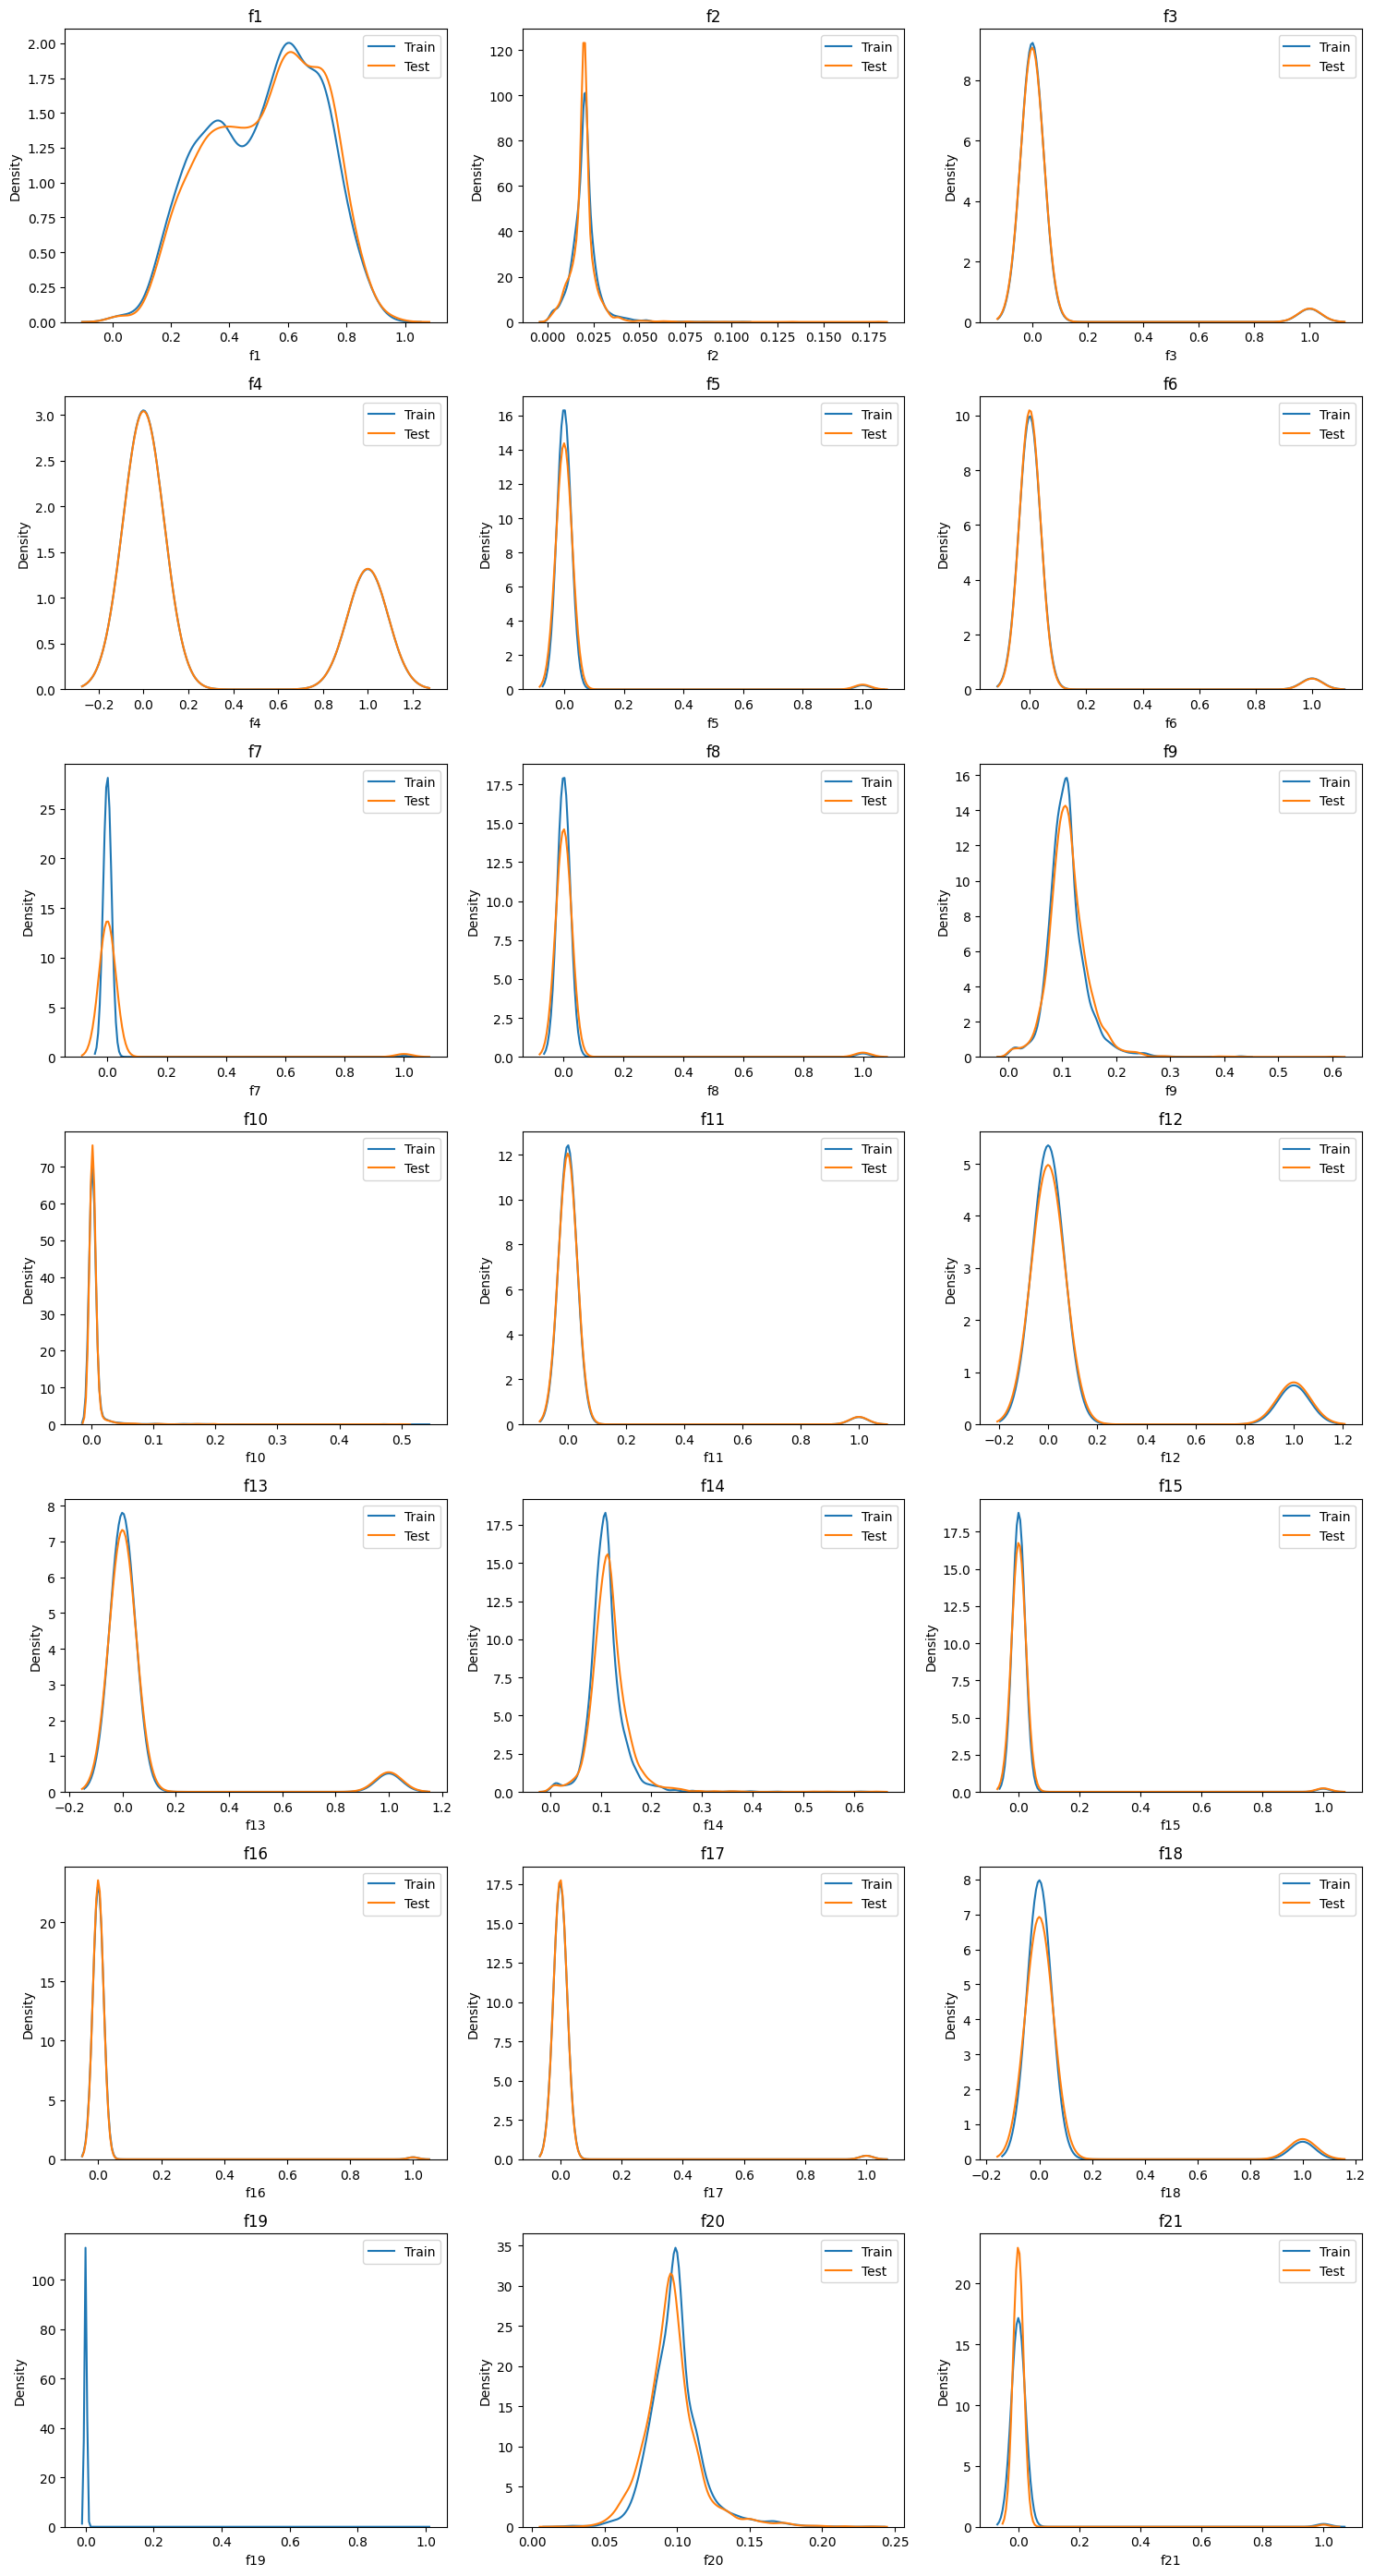

In [214]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(X.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.kdeplot(
        train[col],
        label="Train",
        ax=axes[i]
    )

    sns.kdeplot(
        test[col],
        label="Test",
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 2- CatBoost Using Optuna for Hyper Params

## Hyperparameter Optimization

In [215]:
import optuna

from sklearn.metrics import f1_score
from sklearn.model_selection import StratifiedKFold

from catboost import CatBoostClassifier

In [216]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

# Objective Function

وهذه هي الدالة التي سيحاول Optuna تحسينها.

In [217]:
def objective(trial):

    params = {

        "iterations": trial.suggest_int(
            "iterations",
            300,
            1200
        ),

        "depth": trial.suggest_int(
            "depth",
            4,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.2,
            log=True
        ),

        "l2_leaf_reg": trial.suggest_float(
            "l2_leaf_reg",
            1,
            20
        ),

        "bagging_temperature": trial.suggest_float(
            "bagging_temperature",
            0,
            5
        ),

        "random_strength": trial.suggest_float(
            "random_strength",
            0,
            5
        ),

        "border_count": trial.suggest_int(
            "border_count",
            32,
            255
        ),

        "loss_function": "MultiClass",

        "eval_metric": "TotalF1",

        "verbose": False,

        "random_seed": 42

    }

    scores = []

    for train_idx, valid_idx in skf.split(X, y_encoded):

        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]

        y_train = y_encoded[train_idx]
        y_valid = y_encoded[valid_idx]

        model = CatBoostClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=(X_valid, y_valid),
            use_best_model=True,
            verbose=False
        )

        pred = model.predict(X_valid).astype(int)

        score = f1_score(
            y_valid,
            pred,
            average="macro"
        )

        scores.append(score)

    return np.mean(scores)

In [218]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=40,
    show_progress_bar=True
)

[I 2026-06-30 08:51:59,418] A new study created in memory with name: no-name-e4254dd6-c03e-48f5-b027-762c3df9e0de


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-06-30 08:52:44,321] Trial 0 finished with value: 0.9793936434842866 and parameters: {'iterations': 332, 'depth': 10, 'learning_rate': 0.029361081792940467, 'l2_leaf_reg': 14.106351133980523, 'bagging_temperature': 4.798991215709299, 'random_strength': 0.46087122007841874, 'border_count': 130}. Best is trial 0 with value: 0.9793936434842866.
[I 2026-06-30 08:52:58,835] Trial 1 finished with value: 0.9674289273896471 and parameters: {'iterations': 577, 'depth': 8, 'learning_rate': 0.02977518899772481, 'l2_leaf_reg': 15.855834421911576, 'bagging_temperature': 4.629968948600412, 'random_strength': 0.9149228702044554, 'border_count': 63}. Best is trial 0 with value: 0.9793936434842866.
[I 2026-06-30 08:54:22,241] Trial 2 finished with value: 0.9873066542150651 and parameters: {'iterations': 587, 'depth': 10, 'learning_rate': 0.1116674980434814, 'l2_leaf_reg': 8.23497800513662, 'bagging_temperature': 3.9566211442241133, 'random_strength': 0.570864610448279, 'border_count': 155}. Best

In [219]:
print(study.best_value)

print()

print(study.best_params)

0.9945851936714274

{'iterations': 1143, 'depth': 6, 'learning_rate': 0.16353450953718301, 'l2_leaf_reg': 4.4573877909673385, 'bagging_temperature': 0.5463650168166716, 'random_strength': 3.5088090244193055, 'border_count': 241}


In [221]:
# best_params = {
#     "iterations": 935,
#     "depth": 7,
#     "learning_rate": 0.16970534359031292,
#     "l2_leaf_reg": 19.828920596429292,
#     "bagging_temperature": 3.1798562495508746,
#     "random_strength": 0.14190731291072955,
#     "border_count": 249,

#     "loss_function": "MultiClass",
#     "eval_metric": "TotalF1",
#     "random_seed": 42,
#     "verbose": False
# }

best_params ={
    'iterations': 1143,
      'depth': 6,
        'learning_rate': 0.16353450953718301, 
        'l2_leaf_reg': 4.4573877909673385, 
        'bagging_temperature': 0.5463650168166716,
          'random_strength': 3.5088090244193055, 
          'border_count': 241,
              "loss_function": "MultiClass",
    "eval_metric": "TotalF1",
    "random_seed": 42,
    "verbose": False
          }

In [223]:
final_model = CatBoostClassifier(**best_params)

final_model.fit(
    X,
    y_encoded,
    verbose=False
)

In [224]:
test_pred = final_model.predict(X_test)

test_pred = test_pred.astype(int).flatten()

In [225]:
test_labels = le.inverse_transform(test_pred)

In [226]:
submission = pd.DataFrame({
    "ID": test["ID"],
    "target": test_labels
})

submission.head()

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


In [228]:
submission.to_csv(
    "submission_catboost_optuna1.csv",
    index=False
)

In [229]:
submission.shape

(3200, 2)

In [230]:
submission.head()

,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


# مقارنة بين بيس لاين و oputa

In [231]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": final_model.get_feature_importance()
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
9,f10,63.9705
13,f14,10.6372
8,f9,7.7838
11,f12,7.2978
0,f1,2.7087
1,f2,2.2177
19,f20,1.9996
16,f17,1.8576
12,f13,0.3158
2,f3,0.2958


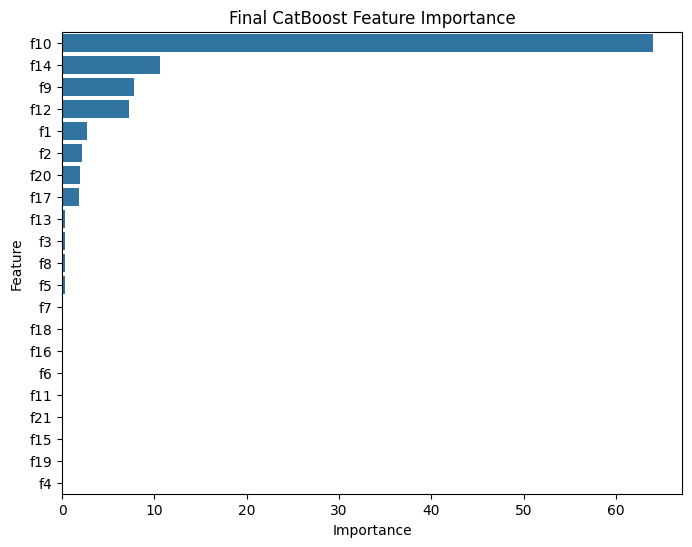

In [232]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Final CatBoost Feature Importance")

plt.show()

## 3- LightGBM

In [233]:
import lightgbm as lgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np

In [234]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

In [235]:
oof_pred = np.zeros(len(X), dtype=int)

test_pred_prob = np.zeros(
    (len(X_test), len(le.classes_))
)

fold_scores = []

In [ ]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_encoded), 1):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    model = lgb.LGBMClassifier(

        objective="multiclass",
        num_class=3,

        n_estimators=500,

        learning_rate=0.05,

        max_depth=6,

        num_leaves=31,

        random_state=42

    )


    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_valid)

    oof_pred[valid_idx] = pred

    score = f1_score(
        y_valid,
        pred,
        average="macro"
    )

    fold_scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

    test_pred_prob += (
        model.predict_proba(X_test) / N_SPLITS
    )

Fold 1: 0.98609
Fold 2: 1.00000
Fold 3: 0.99538
Fold 4: 0.96752
Fold 5: 1.00000


In [237]:
print("="*50)

print("CV Macro F1")

print(np.mean(fold_scores))

CV Macro F1
0.9897981214751803


In [238]:
print(
    classification_report(
        y_encoded,
        oof_pred,
        target_names=le.classes_
    )
)

              precision    recall  f1-score   support

      class1       0.98      1.00      0.99        93
      class2       0.98      0.98      0.98       191
      class3       1.00      1.00      1.00      2916

    accuracy                           1.00      3200
   macro avg       0.99      0.99      0.99      3200
weighted avg       1.00      1.00      1.00      3200



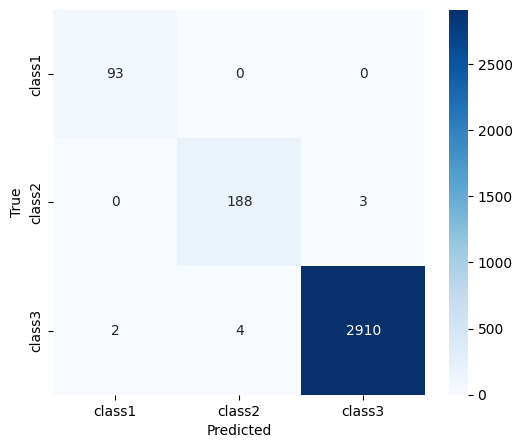

In [239]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_encoded,
    oof_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

In [240]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
13,f14,2125
9,f10,2122
8,f9,2030
19,f20,1628
1,f2,1576
0,f1,1347
11,f12,749
16,f17,391
12,f13,44
17,f18,22


In [241]:
test_pred = np.argmax(
    test_pred_prob,
    axis=1
)

test_labels = le.inverse_transform(
    test_pred
)

submission = pd.DataFrame({

    "ID": test["ID"],

    "target": test_labels

})

submission.to_csv(
    "submission_lightgbm_baseline.csv",
    index=False
)

# 4- LightGBM regularized and XgBoost togather for blend

In [163]:
SEEDS = [42, 2024, 7, 13, 99]
N_SPLITS = 5

In [164]:
X = train[features].copy()
X_test = test[features].copy()

le = LabelEncoder()
y = le.fit_transform(train[TARGET_COL])

print("Classes:", list(le.classes_))
print("Encoded classes:", dict(zip(le.classes_, range(len(le.classes_)))))

Classes: ['class1', 'class2', 'class3']
Encoded classes: {'class1': 0, 'class2': 1, 'class3': 2}


In [165]:
# XGBoost
from xgboost import XGBClassifier

def build_xgb(seed):
    return XGBClassifier(
        objective="multi:softprob",
        num_class=len(le.classes_),
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.80,
        colsample_bytree=0.80,
        min_child_weight=1,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=seed,
        tree_method="hist",
        eval_metric="mlogloss",
        n_jobs=-1
    )

In [166]:
# LightGBM regularized
import lightgbm as lgb

def build_lgb_regularized(seed):
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=len(le.classes_),
        n_estimators=800,
        learning_rate=0.035,
        max_depth=4,
        num_leaves=15,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.01,
        reg_lambda=1.0,
        min_child_samples=10,
        random_state=seed,
        verbose=-1,
        n_jobs=-1
    )

In [167]:
def cv_predict_proba(model_name, model_builder, X, y, X_test, use_sample_weight=False):
    n_classes = len(np.unique(y))
    
    oof_proba = np.zeros((len(X), n_classes))
    test_proba = np.zeros((len(X_test), n_classes))
    
    fold_scores = []
    
    for seed in SEEDS:
        skf = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=seed
        )
        
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]
            
            model = model_builder(seed + fold)
            
            if use_sample_weight:
                sw = compute_sample_weight(class_weight="balanced", y=y_tr)
                try:
                    model.fit(X_tr, y_tr, sample_weight=sw)
                except TypeError:
                    model.fit(X_tr, y_tr)
            else:
                model.fit(X_tr, y_tr)
            
            val_proba = model.predict_proba(X_val)
            val_pred = np.argmax(val_proba, axis=1)
            
            oof_proba[val_idx] += val_proba / len(SEEDS)
            test_proba += model.predict_proba(X_test) / (len(SEEDS) * N_SPLITS)
            
            score = f1_score(y_val, val_pred, average="macro")
            fold_scores.append(score)
    
    oof_pred = np.argmax(oof_proba, axis=1)
    oof_score = f1_score(y, oof_pred, average="macro")
    
    print("=" * 60)
    print(model_name)
    print("Fold mean:", round(np.mean(fold_scores), 6))
    print("Fold std :", round(np.std(fold_scores), 6))
    print("OOF Macro-F1:", round(oof_score, 6))
    print("=" * 60)
    
    print(classification_report(y, oof_pred, target_names=le.classes_))
    
    return {
        "name": model_name,
        "oof_proba": oof_proba,
        "test_proba": test_proba,
        "oof_score": oof_score,
        "fold_scores": fold_scores
    }

In [168]:
results = {}

results["xgb"] = cv_predict_proba(
    model_name="XGBoost baseline",
    model_builder=build_xgb,
    X=X,
    y=y,
    X_test=X_test,
    use_sample_weight=False
)

results["lgb_reg"] = cv_predict_proba(
    model_name="LightGBM regularized",
    model_builder=build_lgb_regularized,
    X=X,
    y=y,
    X_test=X_test,
    use_sample_weight=False
)

XGBoost baseline
Fold mean: 0.98406
Fold std : 0.013042
OOF Macro-F1: 0.989158
              precision    recall  f1-score   support

      class1       0.98      0.99      0.98        93
      class2       0.98      0.99      0.98       191
      class3       1.00      1.00      1.00      2916

    accuracy                           1.00      3200
   macro avg       0.99      0.99      0.99      3200
weighted avg       1.00      1.00      1.00      3200

LightGBM regularized
Fold mean: 0.991019
Fold std : 0.009627
OOF Macro-F1: 0.992656
              precision    recall  f1-score   support

      class1       0.98      1.00      0.99        93
      class2       0.98      1.00      0.99       191
      class3       1.00      1.00      1.00      2916

    accuracy                           1.00      3200
   macro avg       0.99      1.00      0.99      3200
weighted avg       1.00      1.00      1.00      3200



In [169]:
print(f"model: {list(results.keys())}")
print(f"oof_macro_f1: {[results[k]["oof_score"] for k in results.keys()]}")


model: ['xgb', 'lgb_reg']
oof_macro_f1: [0.9891581463953818, 0.9926563805699122]


In [170]:
def make_submission(filename, test_proba):
    pred_encoded = np.argmax(test_proba, axis=1)
    pred_labels = le.inverse_transform(pred_encoded)
    
    pred_df = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET_COL: pred_labels
    })
    
    # Preserve sample submission ID order
    submission = sample[[ID_COL]].merge(pred_df, on=ID_COL, how="left")
    
    assert submission[TARGET_COL].isna().sum() == 0
    assert submission.shape[0] == sample.shape[0]
    
    submission.to_csv(filename, index=False)
    
    print(filename)
    print(submission[TARGET_COL].value_counts())
    display(submission.head())
    
    return submission

In [171]:
# 1) LightGBM regularized
sub_lgb = make_submission(
    "submission_lgb_regularized.csv",
    results["lgb_reg"]["test_proba"]
)

submission_lgb_regularized.csv
target
class3    2932
class2     187
class1      81
Name: count, dtype: int64


,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


In [172]:
# 1) LightGBM regularized
sub_lgb = make_submission(
    "submission_xgb_para.csv",
    results["xgb"]["test_proba"]
)

submission_xgb_para.csv
target
class3    2935
class2     185
class1      80
Name: count, dtype: int64


,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


# 5- blend Xgb and lightGbm

In [173]:
def evaluate_blend(blend_name, weights):
    proba = np.zeros_like(results[list(weights.keys())[0]]["oof_proba"])
    
    for model_name, w in weights.items():
        proba += results[model_name]["oof_proba"] * w
    
    pred = np.argmax(proba, axis=1)
    score = f1_score(y, pred, average="macro")
    
    print(blend_name, "OOF Macro-F1:", round(score, 6))
    print(classification_report(y, pred, target_names=le.classes_))
    
    return score, proba

In [174]:
blend_defs = {
    "xgb_lgb_blend": {
        "xgb": 0.50,
        "lgb_reg": 0.50
    }
}

blend_scores = {}

for blend_name, weights in blend_defs.items():
    score, _ = evaluate_blend(blend_name, weights)
    blend_scores[blend_name] = score

xgb_lgb_blend OOF Macro-F1: 0.994477
              precision    recall  f1-score   support

      class1       0.99      1.00      0.99        93
      class2       0.98      1.00      0.99       191
      class3       1.00      1.00      1.00      2916

    accuracy                           1.00      3200
   macro avg       0.99      1.00      0.99      3200
weighted avg       1.00      1.00      1.00      3200



In [175]:
def make_submission(filename, test_proba):
    pred_encoded = np.argmax(test_proba, axis=1)
    pred_labels = le.inverse_transform(pred_encoded)
    
    pred_df = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET_COL: pred_labels
    })
    
    # Preserve sample submission ID order
    submission = sample[[ID_COL]].merge(pred_df, on=ID_COL, how="left")
    
    assert submission[TARGET_COL].isna().sum() == 0
    assert submission.shape[0] == sample.shape[0]
    
    submission.to_csv(filename, index=False)
    
    print(filename)
    print(submission[TARGET_COL].value_counts())
    display(submission.head())
    
    return submission

In [176]:
xgb_lgb_test_proba = (
    0.50 * results["xgb"]["test_proba"] +
    0.50 * results["lgb_reg"]["test_proba"]
)

sub_xgb_lgb = make_submission(
    "submission_xgb_lgb_blend.csv",
    xgb_lgb_test_proba
)


submission_xgb_lgb_blend.csv
target
class3    2933
class2     186
class1      81
Name: count, dtype: int64


,ID,target
0,10000,class3
1,10001,class3
2,10002,class3
3,10003,class3
4,10004,class3


# Random Search for xgboost

In [95]:
from sklearn.model_selection import ParameterSampler, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from xgboost import XGBClassifier

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

RANDOM_SEARCH_ITER = 40
CV_SEEDS = [42, 2024]   # نبدأ باثنين لتخفيف الوقت
N_SPLITS = 5

n_classes = len(le.classes_)

In [96]:
param_space = {
    "n_estimators": [350, 450, 500, 600, 700, 850, 1000],
    "learning_rate": [0.02, 0.025, 0.03, 0.04, 0.05, 0.06],
    "max_depth": [3, 4, 5, 6, 7],
    "subsample": [0.75, 0.80, 0.85, 0.90, 0.95, 1.00],
    "colsample_bytree": [0.75, 0.80, 0.85, 0.90, 0.95, 1.00],
    "min_child_weight": [1, 2, 3, 5, 8, 10],
    "reg_alpha": [0.0, 0.005, 0.01, 0.05, 0.1],
    "reg_lambda": [0.8, 1.0, 1.5, 2.0, 3.0, 5.0],
    "gamma": [0.0, 0.01, 0.02, 0.05, 0.1],
}

In [97]:
def train_xgb_random_candidate(name, params):
    oof_proba = np.zeros((len(X), n_classes))
    test_proba = np.zeros((len(X_test), n_classes))
    
    fold_scores = []
    
    for cv_seed in CV_SEEDS:
        skf = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=cv_seed
        )
        
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y[tr_idx], y[val_idx]
            
            model = XGBClassifier(
                objective="multi:softprob",
                num_class=n_classes,
                tree_method="hist",
                eval_metric="mlogloss",
                n_jobs=-1,
                random_state=cv_seed + fold,
                **params
            )
            
            model.fit(X_tr, y_tr)
            
            val_proba = model.predict_proba(X_val)
            val_pred = np.argmax(val_proba, axis=1)
            
            oof_proba[val_idx] += val_proba / len(CV_SEEDS)
            test_proba += model.predict_proba(X_test) / (len(CV_SEEDS) * N_SPLITS)
            
            fold_score = f1_score(y_val, val_pred, average="macro")
            fold_scores.append(fold_score)
    
    oof_pred = np.argmax(oof_proba, axis=1)
    oof_score = f1_score(y, oof_pred, average="macro")
    
    pred_labels = le.inverse_transform(np.argmax(test_proba, axis=1))
    
    submission = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET_COL: pred_labels
    })
    
    submission = sample[[ID_COL]].merge(submission, on=ID_COL, how="left")
    
    return {
        "name": name,
        "params": params,
        "oof_score": oof_score,
        "fold_mean": np.mean(fold_scores),
        "fold_std": np.std(fold_scores),
        "test_proba": test_proba,
        "submission": submission,
        "pred_counts": submission[TARGET_COL].value_counts().to_dict()
    }

In [98]:
sampled_params = list(ParameterSampler(
    param_space,
    n_iter=RANDOM_SEARCH_ITER,
    random_state=2026
))

random_results = {}

for i, params in enumerate(sampled_params, 1):
    name = f"xgb_random_{i:02d}"
    print("=" * 80)
    print("Training:", name)
    print(params)
    
    result = train_xgb_random_candidate(name, params)
    random_results[name] = result
    
    print("OOF Macro-F1:", round(result["oof_score"], 6))
    print("Fold mean   :", round(result["fold_mean"], 6))
    print("Fold std    :", round(result["fold_std"], 6))
    print("Pred counts :", result["pred_counts"])


Training: xgb_random_01
{'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.005, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.025, 'gamma': 0.01, 'colsample_bytree': 0.85}
OOF Macro-F1: 0.975658
Fold mean   : 0.97356
Fold std    : 0.015198
Pred counts : {'class3': 2931, 'class2': 189, 'class1': 80}
Training: xgb_random_02
{'subsample': 0.85, 'reg_lambda': 0.8, 'reg_alpha': 0.005, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.04, 'gamma': 0.05, 'colsample_bytree': 0.9}
OOF Macro-F1: 0.982705
Fold mean   : 0.976506
Fold std    : 0.016541
Pred counts : {'class3': 2934, 'class2': 186, 'class1': 80}
Training: xgb_random_03
{'subsample': 0.75, 'reg_lambda': 5.0, 'reg_alpha': 0.0, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.02, 'gamma': 0.02, 'colsample_bytree': 0.9}
OOF Macro-F1: 0.973838
Fold mean   : 0.969898
Fold std    : 0.01618
Pred counts : {'class3': 2929, 'class2': 191, 'class1': 8

In [99]:
rows = []

for name, r in random_results.items():
    counts = r["pred_counts"]
    
    rows.append({
        "candidate": name,
        "oof_score": r["oof_score"],
        "fold_mean": r["fold_mean"],
        "fold_std": r["fold_std"],
        "pred_class1": counts.get("class1", 0),
        "pred_class2": counts.get("class2", 0),
        "pred_class3": counts.get("class3", 0),
        "params": r["params"]
    })

random_summary = pd.DataFrame(rows).sort_values(
    ["oof_score", "fold_std"],
    ascending=[False, True]
)

display(random_summary)

,candidate,oof_score,fold_mean,fold_std,pred_class1,pred_class2,pred_class3,params
12,xgb_random_13,0.9846,0.9785,0.0144,80,186,2934,"{'subsample': 0.95, 'reg_lambda': 3.0, 'reg_al..."
21,xgb_random_22,0.9846,0.9779,0.0146,80,186,2934,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alp..."
35,xgb_random_36,0.9837,0.9793,0.0149,80,186,2934,"{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alp..."
39,xgb_random_40,0.9836,0.9793,0.0148,81,186,2933,"{'subsample': 1.0, 'reg_lambda': 0.8, 'reg_alp..."
23,xgb_random_24,0.9836,0.9784,0.0144,80,185,2935,"{'subsample': 0.75, 'reg_lambda': 1.0, 'reg_al..."
8,xgb_random_09,0.9827,0.9764,0.0157,81,186,2933,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alp..."
22,xgb_random_23,0.9827,0.9788,0.0162,81,186,2933,"{'subsample': 0.95, 'reg_lambda': 3.0, 'reg_al..."
1,xgb_random_02,0.9827,0.9765,0.0165,80,186,2934,"{'subsample': 0.85, 'reg_lambda': 0.8, 'reg_al..."
30,xgb_random_31,0.9818,0.9774,0.0157,80,186,2934,"{'subsample': 0.85, 'reg_lambda': 2.0, 'reg_al..."
38,xgb_random_39,0.9810,0.9766,0.0139,80,186,2934,"{'subsample': 0.75, 'reg_lambda': 5.0, 'reg_al..."


In [100]:
selected_candidates = random_summary.copy()

# فلترة خفيفة لمنع الموديلات الغريبة جدًا في التوزيع
selected_candidates = selected_candidates[
    (selected_candidates["pred_class1"].between(60, 110)) &
    (selected_candidates["pred_class2"].between(150, 220)) &
    (selected_candidates["pred_class3"].between(2850, 2990))
].copy()

selected_candidates = selected_candidates.sort_values(
    ["oof_score", "fold_std"],
    ascending=[False, True]
)

display(selected_candidates.head(10))


,candidate,oof_score,fold_mean,fold_std,pred_class1,pred_class2,pred_class3,params
12,xgb_random_13,0.9846,0.9785,0.0144,80,186,2934,"{'subsample': 0.95, 'reg_lambda': 3.0, 'reg_al..."
21,xgb_random_22,0.9846,0.9779,0.0146,80,186,2934,"{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alp..."
35,xgb_random_36,0.9837,0.9793,0.0149,80,186,2934,"{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alp..."
39,xgb_random_40,0.9836,0.9793,0.0148,81,186,2933,"{'subsample': 1.0, 'reg_lambda': 0.8, 'reg_alp..."
23,xgb_random_24,0.9836,0.9784,0.0144,80,185,2935,"{'subsample': 0.75, 'reg_lambda': 1.0, 'reg_al..."
8,xgb_random_09,0.9827,0.9764,0.0157,81,186,2933,"{'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alp..."
22,xgb_random_23,0.9827,0.9788,0.0162,81,186,2933,"{'subsample': 0.95, 'reg_lambda': 3.0, 'reg_al..."
1,xgb_random_02,0.9827,0.9765,0.0165,80,186,2934,"{'subsample': 0.85, 'reg_lambda': 0.8, 'reg_al..."
30,xgb_random_31,0.9818,0.9774,0.0157,80,186,2934,"{'subsample': 0.85, 'reg_lambda': 2.0, 'reg_al..."
38,xgb_random_39,0.9810,0.9766,0.0139,80,186,2934,"{'subsample': 0.75, 'reg_lambda': 5.0, 'reg_al..."


In [102]:
top_names = selected_candidates.head(5)["candidate"].tolist()

for name in top_names:
    r = random_results[name]
    
    print("=" * 80)
    print(name)
    print("OOF Macro-F1:", r["oof_score"])
    print("Fold mean   :", r["fold_mean"])
    print("Fold std    :", r["fold_std"])
    print("Pred counts :", r["pred_counts"])
    print("Params:")
    print(r["params"])



xgb_random_13
OOF Macro-F1: 0.9845635009998639
Fold mean   : 0.9784507512648781
Fold std    : 0.014438767304824742
Pred counts : {'class3': 2934, 'class2': 186, 'class1': 80}
Params:
{'subsample': 0.95, 'reg_lambda': 3.0, 'reg_alpha': 0.005, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.0, 'colsample_bytree': 0.85}
xgb_random_22
OOF Macro-F1: 0.9845635009998639
Fold mean   : 0.9778895628360791
Fold std    : 0.014554334060464745
Pred counts : {'class3': 2934, 'class2': 186, 'class1': 80}
Params:
{'subsample': 0.9, 'reg_lambda': 5.0, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.06, 'gamma': 0.02, 'colsample_bytree': 0.9}
xgb_random_36
OOF Macro-F1: 0.9836630734230271
Fold mean   : 0.9793151940157045
Fold std    : 0.014930023612175302
Pred counts : {'class3': 2934, 'class2': 186, 'class1': 80}
Params:
{'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.005, 'n_estimators': 600, 'min_child

In [103]:
top_to_save = selected_candidates.head(3)["candidate"].tolist()

for name in top_to_save:
    filename = f"submission_{name}.csv"
    random_results[name]["submission"].to_csv(filename, index=False)
    print("Saved:", filename)


Saved: submission_xgb_random_13.csv
Saved: submission_xgb_random_22.csv
Saved: submission_xgb_random_36.csv


# 7- stacking_logreg

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import lightgbm as lgb
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

STACK_CV_SEEDS = [42, 2024, 7, 13, 99]
N_SPLITS = 5
n_classes = len(le.classes_)

In [82]:
def build_xgb_stack(seed):
    return XGBClassifier(
        objective="multi:softprob",
        num_class=n_classes,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        reg_alpha=0,
        reg_lambda=1,
        gamma=0,
        random_state=seed,
        tree_method="hist",
        eval_metric="mlogloss",
        n_jobs=-1
    )


def build_lgb_stack(seed):
    return lgb.LGBMClassifier(
        objective="multiclass",
        num_class=n_classes,
        n_estimators=800,
        learning_rate=0.035,
        max_depth=4,
        num_leaves=15,
        subsample=0.90,
        colsample_bytree=0.90,
        reg_alpha=0.01,
        reg_lambda=1.0,
        min_child_samples=10,
        random_state=seed,
        verbose=-1,
        n_jobs=-1
    )


def build_rf_stack(seed):
    return RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )


def build_dt_stack(seed):
    return DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=seed
    )

In [83]:
def get_oof_and_test_proba_for_stacking(model_name, model_builder, X_train, y, X_test):
    oof_proba = np.zeros((len(X_train), n_classes))
    test_proba = np.zeros((len(X_test), n_classes))
    
    fold_scores = []
    
    for cv_seed in STACK_CV_SEEDS:
        skf = StratifiedKFold(
            n_splits=N_SPLITS,
            shuffle=True,
            random_state=cv_seed
        )
        
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y), 1):
            X_tr = X_train.iloc[tr_idx]
            X_val = X_train.iloc[val_idx]
            y_tr = y[tr_idx]
            y_val = y[val_idx]
            
            model = model_builder(cv_seed + fold)
            model.fit(X_tr, y_tr)
            
            val_proba = model.predict_proba(X_val)
            val_pred = np.argmax(val_proba, axis=1)
            
            oof_proba[val_idx] += val_proba / len(STACK_CV_SEEDS)
            test_proba += model.predict_proba(X_test) / (len(STACK_CV_SEEDS) * N_SPLITS)
            
            fold_scores.append(f1_score(y_val, val_pred, average="macro"))
    
    oof_pred = np.argmax(oof_proba, axis=1)
    oof_score = f1_score(y, oof_pred, average="macro")
    
    print("=" * 80)
    print(model_name)
    print("OOF Macro-F1:", round(oof_score, 6))
    print("Fold mean   :", round(np.mean(fold_scores), 6))
    print("Fold std    :", round(np.std(fold_scores), 6))
    
    return {
        "name": model_name,
        "oof_proba": oof_proba,
        "test_proba": test_proba,
        "oof_score": oof_score,
        "fold_mean": np.mean(fold_scores),
        "fold_std": np.std(fold_scores)
    }

In [89]:
stack_base_results = {}

stack_base_results["xgb"] = get_oof_and_test_proba_for_stacking(
    "XGBoost",
    build_xgb_stack,
    X,
    y_encoded,
    X_test
)

stack_base_results["lgb"] = get_oof_and_test_proba_for_stacking(
    "LightGBM",
    build_lgb_stack,
    X,
    y_encoded,
    X_test
)

stack_base_results["rf"] = get_oof_and_test_proba_for_stacking(
    "RandomForest",
    build_rf_stack,
    X,
    y_encoded,
    X_test
)

stack_base_results["dt"] = get_oof_and_test_proba_for_stacking(
    "DecisionTree",
    build_dt_stack,
    X,
    y_encoded,
    X_test
)



XGBoost
OOF Macro-F1: 0.989158
Fold mean   : 0.98406
Fold std    : 0.013042
LightGBM
OOF Macro-F1: 0.992656
Fold mean   : 0.991019
Fold std    : 0.009627
RandomForest
OOF Macro-F1: 0.98195
Fold mean   : 0.982448
Fold std    : 0.009514
DecisionTree
OOF Macro-F1: 0.988032
Fold mean   : 0.987789
Fold std    : 0.010288


In [90]:
base_model_names = ["xgb", "lgb", "rf", "dt"]

X_meta = np.hstack([
    stack_base_results[name]["oof_proba"]
    for name in base_model_names
])

X_test_meta = np.hstack([
    stack_base_results[name]["test_proba"]
    for name in base_model_names
])

print("X_meta shape:", X_meta.shape)
print("X_test_meta shape:", X_test_meta.shape)

X_meta shape: (3200, 12)
X_test_meta shape: (3200, 12)


In [91]:
def evaluate_meta_model(C=1.0, class_weight=None):
    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    meta_oof_pred = np.zeros(len(y), dtype=int)
    fold_scores = []
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_meta, y), 1):
        X_tr, X_val = X_meta[tr_idx], X_meta[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        
        meta_model = LogisticRegression(
            C=C,
            class_weight=class_weight,
            # multi_class="multinomial",
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        )
        
        meta_model.fit(X_tr, y_tr)
        
        val_pred = meta_model.predict(X_val)
        meta_oof_pred[val_idx] = val_pred
        
        fold_scores.append(f1_score(y_val, val_pred, average="macro"))
    
    score = f1_score(y, meta_oof_pred, average="macro")
    
    return {
        "C": C,
        "class_weight": class_weight,
        "stack_oof_score": score,
        "fold_mean": np.mean(fold_scores),
        "fold_std": np.std(fold_scores),
        "oof_pred": meta_oof_pred
    }

In [92]:
meta_experiments = []

for C in [0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]:
    meta_experiments.append(evaluate_meta_model(C=C, class_weight=None))
    meta_experiments.append(evaluate_meta_model(C=C, class_weight="balanced"))

meta_summary = pd.DataFrame([
    {
        "C": r["C"],
        "class_weight": r["class_weight"],
        "stack_oof_score": r["stack_oof_score"],
        "fold_mean": r["fold_mean"],
        "fold_std": r["fold_std"]
    }
    for r in meta_experiments
]).sort_values(
    ["stack_oof_score", "fold_std"],
    ascending=[False, True]
)

display(meta_summary)

,C,class_weight,stack_oof_score,fold_mean,fold_std
4,0.3000,None,0.9954,0.9955,0.0070
6,0.5000,None,0.9954,0.9955,0.0070
8,1.0000,None,0.9954,0.9955,0.0070
10,2.0000,None,0.9954,0.9955,0.0070
12,5.0000,None,0.9954,0.9955,0.0070
1,0.0500,balanced,0.9936,0.9937,0.0067
3,0.1000,balanced,0.9936,0.9937,0.0067
5,0.3000,balanced,0.9936,0.9937,0.0067
7,0.5000,balanced,0.9936,0.9937,0.0067
9,1.0000,balanced,0.9936,0.9937,0.0067


In [93]:
baseline_stack_score = stack_base_results["xgb"]["oof_score"]
best_meta_row = meta_summary.iloc[0]

print("XGB baseline OOF:", baseline_stack_score)
print("Best stacking OOF:", best_meta_row["stack_oof_score"])
display(best_meta_row)

XGB baseline OOF: 0.9891581463953818
Best stacking OOF: 0.9953912856088963


C                 0.3000
class_weight        None
stack_oof_score   0.9954
fold_mean         0.9955
fold_std          0.0070
Name: 4, dtype: object

In [94]:
if best_meta_row["stack_oof_score"] > baseline_stack_score:
    best_C = best_meta_row["C"]
    best_class_weight = best_meta_row["class_weight"]
    
    final_meta_model = LogisticRegression(
        C=best_C,
        class_weight=best_class_weight,
        # multi_class="multinomial",
        solver="lbfgs",
        max_iter=5000,
        random_state=42
    )
    
    final_meta_model.fit(X_meta, y)
    
    stack_test_pred = final_meta_model.predict(X_test_meta)
    stack_test_labels = le.inverse_transform(stack_test_pred)
    
    submission_stack = pd.DataFrame({
        ID_COL: test[ID_COL].values,
        TARGET_COL: stack_test_labels
    })
    
    submission_stack = sample[[ID_COL]].merge(
        submission_stack,
        on=ID_COL,
        how="left"
    )
    
    filename = "submission_stacking_logreg.csv"
    submission_stack.to_csv(filename, index=False)
    
    print("Saved:", filename)
    print(submission_stack[TARGET_COL].value_counts())
else:
    print("Stacking did not improve over XGB OOF. Do not save/submit.")

Saved: submission_stacking_logreg.csv
target
class3    2931
class2     188
class1      81
Name: count, dtype: int64


# التجربة النهائية التي تم اعتمادها بشكل كامل ك اخر submission

## تم اختيار ال Xgboost لانه الموديل الوحيد بهذة البرمترات الذي اعطى افضل نتيجة 
## مع العلم جربنا واحد فوق مع ال lightgbm ب parameters مختلفة ما عطى نفس الشي

# ###################-XGBOOST-###################

In [32]:
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score,
    classification_report,
    confusion_matrix
)

import numpy as np
import pandas as pd

In [33]:
N_SPLITS = 5

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=42
)

In [34]:
oof_pred = np.zeros(len(X), dtype=int)

test_pred_prob = np.zeros(
    (len(X_test), len(le.classes_))
)

fold_scores = []

In [ ]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

N_SPLITS = 5

oof_pred = np.zeros(len(X), dtype=int)
test_pred_prob = np.zeros((len(X_test), len(le.classes_)))
fold_scores = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y_encoded), 1):

    X_train = X.iloc[train_idx]
    X_valid = X.iloc[valid_idx]

    y_train = y_encoded[train_idx]
    y_valid = y_encoded[valid_idx]

    model = XGBClassifier(
        objective="multi:softprob",
        num_class=3,
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        reg_alpha=0,
        reg_lambda=1,
        random_state=42,
        tree_method="hist",
        eval_metric="mlogloss"
    )

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(X_valid)

    oof_pred[valid_idx] = pred

    score = f1_score(
        y_valid,
        pred,
        average="macro"
    )

    fold_scores.append(score)

    print(f"Fold {fold}: {score:.5f}")

    test_pred_prob += (
        model.predict_proba(X_test) / N_SPLITS
    )


fold_mean = np.mean(fold_scores)
fold_std = np.std(fold_scores)

oof_macro_f1 = f1_score(
    y_encoded,
    oof_pred,
    average="macro"
)

print("=" * 70)
print(f"Fold mean      : {fold_mean:.6f}")
print(f"Fold std       : {fold_std:.6f}")
print(f"OOF Macro-F1   : {oof_macro_f1:.6f}")

print("=" * 70)
print("OOF Classification Report")
print(
    classification_report(
        y_encoded,
        oof_pred,
        target_names=le.classes_
    )
)

Fold 1: 0.97692
Fold 2: 0.98216
Fold 3: 0.99538
Fold 4: 0.96752
Fold 5: 0.97368
Fold mean      : 0.979132
Fold std       : 0.009411
OOF Macro-F1   : 0.979201
OOF Classification Report
              precision    recall  f1-score   support

      class1       0.97      0.98      0.97        93
      class2       0.96      0.97      0.97       191
      class3       1.00      1.00      1.00      2916

    accuracy                           1.00      3200
   macro avg       0.98      0.98      0.98      3200
weighted avg       1.00      1.00      1.00      3200



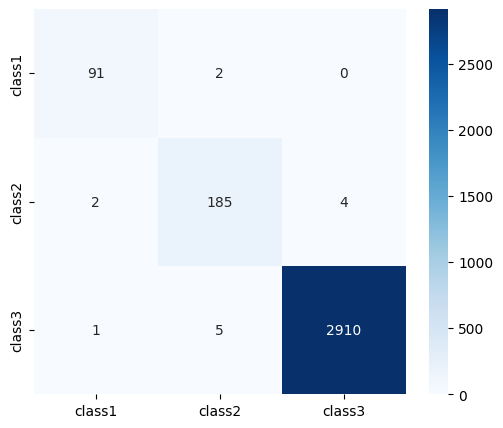

In [43]:
cm = confusion_matrix(
    y_encoded,
    oof_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.show()

In [40]:
test_pred = np.argmax(
    test_pred_prob,
    axis=1
)

submission = pd.DataFrame({

    "ID":test["ID"],

    "target":le.inverse_transform(test_pred)

})

submission.to_csv(
    "Final_Submission1.csv",
    index=False
)

# MLOps Practices: MLflow Experiment Tracking

In [177]:
X, y, X_test, train, test, sample, le, features, ID_COL, TARGET_COL

(         f1     f2  f3  f4  f5  f6  f7  f8     f9    f10  f11  f12  f13  \
 0    0.3800 0.0160   0   0   0   0   0   0 0.1080 0.0009    0    0    0   
 1    0.3700 0.0250   0   0   0   0   0   0 0.0840 0.0051    0    0    0   
 2    0.5700 0.0220   0   0   0   0   0   0 0.1112 0.0019    0    0    0   
 3    0.5400 0.0206   0   1   0   0   0   0 0.1010 0.0002    0    1    0   
 4    0.4200 0.0208   0   0   0   0   0   0 0.1230 0.0072    0    0    0   
 ...     ...    ...  ..  ..  ..  ..  ..  ..    ...    ...  ...  ...  ...   
 3195 0.3200 0.0310   0   0   0   0   0   0 0.2060 0.0001    0    0    0   
 3196 0.3400 0.0160   0   0   0   0   0   0 0.1070 0.0003    0    0    0   
 3197 0.7800 0.0150   0   0   0   0   0   0 0.0880 0.0007    0    0    0   
 3198 0.2700 0.0280   0   0   0   0   0   0 0.1990 0.0001    0    0    0   
 3199 0.4900 0.0206   0   0   0   0   0   0 0.0870 0.0006    1    0    0   
 
         f14  f15  f16  f17  f18  f19    f20  f21  
 0    0.1270    0    1    0    0  

In [182]:
import os
import json
import joblib
import shutil
from pathlib import Path

import numpy as np
import pandas as pd

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm

from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

# -----------------------------
# Directories
# -----------------------------
ARTIFACT_DIR = Path("mlflow_artifacts")
MLFLOW_ARTIFACTS_DIR = Path("mlartifacts")

ARTIFACT_DIR.mkdir(exist_ok=True)
MLFLOW_ARTIFACTS_DIR.mkdir(exist_ok=True)

# -----------------------------
# SQLite backend instead of file:./mlruns
# -----------------------------
TRACKING_DB = "mlflow2.db"
TRACKING_URI = f"sqlite:///{TRACKING_DB}"

mlflow.set_tracking_uri(TRACKING_URI)

EXPERIMENT_NAME = "anonymized_classification_challenge_8_runs"

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)

if experiment is None:
    artifact_location = MLFLOW_ARTIFACTS_DIR.resolve().as_uri()
    experiment_id = mlflow.create_experiment(
        name=EXPERIMENT_NAME,
        artifact_location=artifact_location
    )
    print("Created new experiment:", EXPERIMENT_NAME)
else:
    experiment_id = experiment.experiment_id
    print("Experiment already exists:", EXPERIMENT_NAME)

mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment ID:", experiment_id)

2026/06/30 08:37:03 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/30 08:37:03 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

Created new experiment: anonymized_classification_challenge_8_runs
MLflow tracking URI: sqlite:///mlflow2.db
Experiment ID: 1


In [183]:
# Detect binary and continuous columns if not already defined
try:
    binary_cols
    continuous_cols
except NameError:
    binary_cols = []
    continuous_cols = []

    for c in features:
        vals = pd.concat([train[c], test[c]], axis=0).dropna().unique()
        if set(vals).issubset({0, 1}):
            binary_cols.append(c)
        else:
            continuous_cols.append(c)

target_distribution = {
    str(k): int(v)
    for k, v in train[TARGET_COL].value_counts().to_dict().items()
}

preprocessing_config = {
    "id_col": ID_COL,
    "target_col": TARGET_COL,
    "features": list(features),
    "binary_cols": list(binary_cols),
    "continuous_cols": list(continuous_cols),
    "classes": [str(c) for c in le.classes_],
    "n_train": int(train.shape[0]),
    "n_test": int(test.shape[0]),
    "n_features": int(len(features)),
    "target_distribution": target_distribution
}

with open(ARTIFACT_DIR / "preprocessing_config.json", "w") as f:
    json.dump(preprocessing_config, f, indent=4)

joblib.dump(le, ARTIFACT_DIR / "label_encoder.pkl")

print("Saved preprocessing artifacts:")
print(ARTIFACT_DIR / "preprocessing_config.json")
print(ARTIFACT_DIR / "label_encoder.pkl")

Saved preprocessing artifacts:
mlflow_artifacts\preprocessing_config.json
mlflow_artifacts\label_encoder.pkl


In [184]:
def safe_log_param(key, value):
    """
    MLflow params should be simple values.
    This function converts lists/dicts/np types safely.
    """
    if isinstance(value, (dict, list, tuple)):
        mlflow.log_param(key, json.dumps(value))
    elif isinstance(value, (np.integer, np.floating)):
        mlflow.log_param(key, value.item())
    else:
        mlflow.log_param(key, value)


def safe_log_metric(key, value):
    """
    Skip None / NaN metrics safely.
    """
    if value is None:
        return
    
    try:
        if pd.isna(value):
            return
    except Exception:
        pass
    
    mlflow.log_metric(key, float(value))


def log_completed_experiment(
    run_name,
    source_notebook,
    model_family,
    params,
    metrics,
    notes,
    submission_file=None,
    extra_artifacts=None,
    tags=None
):
    """
    Logs an already completed experiment to MLflow.
    This is useful because we already ran many experiments during exploration.
    """
    
    with mlflow.start_run(run_name=run_name):
        # -----------------------------
        # Tags
        # -----------------------------
        mlflow.set_tag("source_notebook", source_notebook)
        mlflow.set_tag("model_family", model_family)
        mlflow.set_tag("notes", notes)
        
        if tags:
            for k, v in tags.items():
                mlflow.set_tag(k, str(v))
        
        # -----------------------------
        # Params
        # -----------------------------
        for k, v in params.items():
            safe_log_param(k, v)
        
        # -----------------------------
        # Metrics
        # -----------------------------
        for k, v in metrics.items():
            safe_log_metric(k, v)
        
        # -----------------------------
        # Preprocessing artifacts
        # -----------------------------
        mlflow.log_artifact(str(ARTIFACT_DIR / "preprocessing_config.json"))
        mlflow.log_artifact(str(ARTIFACT_DIR / "label_encoder.pkl"))
        
        # -----------------------------
        # Submission artifact
        # -----------------------------
        if submission_file is not None:
            submission_path = Path(submission_file)
            if submission_path.exists():
                mlflow.log_artifact(str(submission_path))
            else:
                print(f"Warning: submission file not found: {submission_file}")
        
        # -----------------------------
        # Extra artifacts
        # -----------------------------
        if extra_artifacts:
            for artifact in extra_artifacts:
                artifact_path = Path(artifact)
                if artifact_path.exists():
                    mlflow.log_artifact(str(artifact_path))
                else:
                    print(f"Warning: artifact not found: {artifact}")
        
        print(f"Logged MLflow run: {run_name}")

In [185]:
experiment_runs = [
    # =========================================================
    # Experiments from fite-classification-challenge.ipynb
    # =========================================================
    {
        "run_name": "01_catboost_optuna_from_fite",
        "source_notebook": "fite-classification-challenge.ipynb",
        "model_family": "CatBoost",
        "params": {
            "optimizer": "Optuna",
            "loss_function": "MultiClass",
            "eval_metric": "TotalF1",
            "random_seed": 42,
            "model_type": "CatBoostClassifier"
        },
        "metrics": {
            "public_score": 0.97566
        },
        "notes": "CatBoost Optuna submission from teammate notebook. Rejected because public score was lower than XGBoost.",
        "submission_file": "submission_catboost_optuna.csv",
        "tags": {
            "selected_model": "false"
        }
    },

    {
        "run_name": "02_lightgbm_baseline_from_fite",
        "source_notebook": "fite-classification-challenge.ipynb",
        "model_family": "LightGBM",
        "params": {
            "objective": "multiclass",
            "num_class": 3,
            "model_type": "LGBMClassifier",
            "cv": "StratifiedKFold_5",
            "random_state": 42
        },
        "metrics": {
            "public_score": 0.98046
        },
        "notes": "LightGBM baseline submission from teammate notebook. Rejected because public score was lower than XGBoost.",
        "submission_file": "submission_lightgbm_baseline.csv",
        "tags": {
            "selected_model": "false"
        }
    },

    {
        "run_name": "03_xgboost_baseline_from_fite_selected_The Last One In NoteBoke",
        "source_notebook": "fite-classification-challenge.ipynb",
        "model_family": "XGBoost",
        "params": {
            "objective": "multi:softprob",
            "num_class": 3,
            "n_estimators": 500,
            "learning_rate": 0.05,
            "max_depth": 6,
            "subsample": 0.8,
            "colsample_bytree": 0.8,
            "min_child_weight": 1,
            "reg_alpha": 0,
            "reg_lambda": 1,
            "random_state": 42,
            "tree_method": "hist",
            "eval_metric": "mlogloss",
            "cv": "StratifiedKFold_5"
        },
        "metrics": {
            "public_score": 0.98435
        },
        "notes": "Selected final model. Best public leaderboard score among safe submitted models.",
        "submission_file": "submission_xgboost_baseline.csv",
        "tags": {
            "selected_model": "true"
        }
    },

    # =========================================================
    # Experiments from Marwan_NoteBook.ipynb
    # =========================================================
    {
        "run_name": "04_lightgbm_regularized_from_marwan",
        "source_notebook": "Marwan_NoteBook.ipynb",
        "model_family": "LightGBM",
        "params": {
            "objective": "multiclass",
            "num_class": 3,
            "n_estimators": 800,
            "learning_rate": 0.035,
            "max_depth": 4,
            "num_leaves": 15,
            "subsample": 0.90,
            "colsample_bytree": 0.90,
            "reg_alpha": 0.01,
            "reg_lambda": 1.0,
            "min_child_samples": 10,
            "cv": "Repeated_StratifiedKFold_5seeds"
        },
        "metrics": {
            "oof_macro_f1": 0.992656,
            "fold_mean_macro_f1": 0.991019,
            "fold_std_macro_f1": 0.009627
        },
        "notes": "Regularized LightGBM from Marwan notebook. High OOF but not selected due to public mismatch.",
        "submission_file": "submission_lgb_regularized.csv",
        "tags": {
            "selected_model": "false"
        }
    },

    {
        "run_name": "05_xgb_lgb_blend_from_marwan",
        "source_notebook": "Marwan_NoteBook.ipynb",
        "model_family": "Blend",
        "params": {
            "blend_type": "probability_average",
            "xgb_weight": 0.50,
            "lgb_weight": 0.50,
            "base_models": "xgboost_baseline + lightgbm_regularized"
        },
        "metrics": {
            "oof_macro_f1": 0.994477,
            "public_score": 0.98046
        },
        "notes": "Probability blend between XGBoost and LightGBM. Rejected because public score decreased.",
        "submission_file": "submission_xgb_lgb_blend.csv",
        "tags": {
            "selected_model": "false"
        }
    },

    {
    "run_name": "06_xgb_random_search_top3_from_marwan",
    "source_notebook": "Marwan_NoteBook.ipynb",
    "model_family": "XGBoost",
    "params": {
        "search_type": "random_search",
        "n_iter": 40,
        "cv": "Repeated_StratifiedKFold",
        "cv_seeds": [42, 2024],
        "n_splits": 5,
        "selection_rule": "top_3_by_oof_macro_f1",
        "top_candidates": [
            "xgb_random_13",
            "xgb_random_22",
            "xgb_random_36"
        ],
        "parameter_space": {
            "n_estimators": [350, 450, 500, 600, 700, 850, 1000],
            "learning_rate": [0.02, 0.025, 0.03, 0.04, 0.05, 0.06],
            "max_depth": [3, 4, 5, 6, 7],
            "subsample": [0.75, 0.80, 0.85, 0.90, 0.95, 1.00],
            "colsample_bytree": [0.75, 0.80, 0.85, 0.90, 0.95, 1.00],
            "min_child_weight": [1, 2, 3, 5, 8, 10],
            "reg_alpha": [0.0, 0.005, 0.01, 0.05, 0.1],
            "reg_lambda": [0.8, 1.0, 1.5, 2.0, 3.0, 5.0],
            "gamma": [0.0, 0.01, 0.02, 0.05, 0.1]
        }
    },
    "metrics": {
        "best_random_oof_macro_f1": 0.984564,
        "best_random_fold_mean": 0.978451,
        "best_random_fold_std": 0.014439,
        "xgb_random_13_oof": 0.984564,
        "xgb_random_13_fold_mean": 0.978451,
        "xgb_random_13_fold_std": 0.014439,
        "xgb_random_22_oof": 0.984564,
        "xgb_random_22_fold_mean": 0.977890,
        "xgb_random_22_fold_std": 0.014554,
        "xgb_random_36_oof": 0.983663,
        "xgb_random_36_fold_mean": 0.979315,
        "xgb_random_36_fold_std": 0.014930
    },
    "notes": (
        "XGBoost random search experiment from Marwan notebook. "
        "We sampled 40 parameter configurations and saved the top three candidate submissions "
        "based on OOF Macro-F1: xgb_random_13, xgb_random_22, and xgb_random_36. "
        "The experiment was used for model exploration but was not selected as final because "
        "the original XGBoost baseline remained the strongest public leaderboard submission."
    ),
    "submission_file": "submission_xgb_random_13.csv",
    "extra_artifacts": [
        "submission_xgb_random_22.csv",
        "submission_xgb_random_36.csv"
    ],
    "tags": {
        "selected_model": "false",
        "experiment_stage": "random_search",
        "num_saved_submissions": "3"
    }
},

    {
        "run_name": "07_stacking_logreg_from_marwan",
        "source_notebook": "Marwan_NoteBook.ipynb",
        "model_family": "Stacking",
        "params": {
            "base_models": "xgb,lgb,rf,dt",
            "meta_model": "LogisticRegression",
            "C": 0.3,
            "class_weight": "None",
            "solver": "lbfgs",
            "cv": "OOF_stacking"
        },
        "metrics": {
            "stack_oof_score": 0.9953912856088963,
            "fold_mean": 0.995486,
            "fold_std": 0.006954,
            "public_score": 0.98046
        },
        "notes": "Stacking model. Very high OOF, rejected because it did not generalize to public leaderboard.",
        "submission_file": "submission_stacking_logreg.csv",
        "tags": {
            "selected_model": "false"
        }
    }
]

In [ ]:
for run in experiment_runs:
    log_completed_experiment(
        run_name=run["run_name"],
        source_notebook=run["source_notebook"],
        model_family=run["model_family"],
        params=run["params"],
        metrics=run["metrics"],
        notes=run["notes"],
        submission_file=run.get("submission_file"),
        extra_artifacts=run.get("extra_artifacts"),
        tags=run.get("tags")
    )

print("Logged all 7 experiments to MLflow.")

Logged MLflow run: 01_catboost_optuna_from_fite
Logged MLflow run: 02_lightgbm_baseline_from_fite
Logged MLflow run: 03_xgboost_baseline_from_fite_selected_The Last One In NoteBoke
Logged MLflow run: 04_lightgbm_regularized_from_marwan
Logged MLflow run: 05_xgb_lgb_blend_from_marwan
Logged MLflow run: 06_xgb_random_search_top3_from_marwan
Logged MLflow run: 07_stacking_logreg_from_marwan
Logged all 8 experiments to MLflow.


In [187]:
# Close any active failed MLflow run
if mlflow.active_run() is not None:
    mlflow.end_run()

best_xgb_params = {
    "objective": "multi:softprob",
    "num_class": len(le.classes_),
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 1,
    "reg_alpha": 0,
    "reg_lambda": 1,
    "random_state": 42,
    "tree_method": "hist",
    "eval_metric": "mlogloss",
    "n_jobs": -1
}

with mlflow.start_run(run_name="09_final_best_xgboost_model_artifact"):
    mlflow.set_tag("source_notebook", "final_mlops_section")
    mlflow.set_tag("model_family", "XGBoost")
    mlflow.set_tag("selected_model", "true")
    mlflow.set_tag("purpose", "final_model_artifact")
    
    # Log parameters
    for k, v in best_xgb_params.items():
        safe_log_param(k, v)
    
    # Train final model on full training data
    final_best_model = XGBClassifier(**best_xgb_params)
    final_best_model.fit(X, y)
    
    # Log final known score
    mlflow.log_metric("public_score", 0.98435)
    
    # -----------------------------
    # Save model using joblib only
    # -----------------------------
    model_joblib_path = ARTIFACT_DIR / "final_xgboost_model.pkl"
    model_params_path = ARTIFACT_DIR / "final_xgboost_params.json"
    
    joblib.dump(final_best_model, model_joblib_path)
    
    with open(model_params_path, "w") as f:
        json.dump(best_xgb_params, f, indent=4)
    
    mlflow.log_artifact(
        str(model_joblib_path),
        artifact_path="final_model"
    )
    
    mlflow.log_artifact(
        str(model_params_path),
        artifact_path="final_model"
    )
    
    # -----------------------------
    # Log preprocessing artifacts
    # -----------------------------
    mlflow.log_artifact(
        str(ARTIFACT_DIR / "preprocessing_config.json"),
        artifact_path="preprocessing"
    )
    
    mlflow.log_artifact(
        str(ARTIFACT_DIR / "label_encoder.pkl"),
        artifact_path="preprocessing"
    )
    
    # -----------------------------
    # Log final submission
    # -----------------------------
    final_submission_path = Path("submission_xgboost_baseline.csv")
    
    if final_submission_path.exists():
        mlflow.log_artifact(
            str(final_submission_path),
            artifact_path="submission"
        )
    else:
        print("Warning: submission_xgboost_baseline.csv not found.")
    
    print("Final best XGBoost model logged successfully.")
    print("Model artifact:", model_joblib_path)
    print("Params artifact:", model_params_path)

Final best XGBoost model logged successfully.
Model artifact: mlflow_artifacts\final_xgboost_model.pkl
Params artifact: mlflow_artifacts\final_xgboost_params.json


In [188]:
mlflow_experiment_summary = pd.DataFrame([
    {
        "run_name": r["run_name"],
        "source_notebook": r["source_notebook"],
        "model_family": r["model_family"],
        "cv_or_oof_score": (
            r["metrics"].get("cv_macro_f1")
            or r["metrics"].get("oof_macro_f1")
            or r["metrics"].get("strong_oof_score")
            or r["metrics"].get("stack_oof_score")
        ),
        "public_score": r["metrics"].get("public_score"),
        "decision": (
            "Selected"
            if r["run_name"] == "03_xgboost_baseline_from_fite_selected"
            else "Rejected / Diagnostic"
        )
    }
    for r in experiment_runs
])

display(
    mlflow_experiment_summary.sort_values(
        ["decision", "public_score", "cv_or_oof_score"],
        ascending=[False, False, False]
    )
)

,run_name,source_notebook,model_family,cv_or_oof_score,public_score,decision
2,03_xgboost_baseline_from_fite_selected_The Las...,fite-classification-challenge.ipynb,XGBoost,NaN,0.9843,Rejected / Diagnostic
6,07_stacking_logreg_from_marwan,Marwan_NoteBook.ipynb,Stacking,0.9954,0.9805,Rejected / Diagnostic
4,05_xgb_lgb_blend_from_marwan,Marwan_NoteBook.ipynb,Blend,0.9945,0.9805,Rejected / Diagnostic
1,02_lightgbm_baseline_from_fite,fite-classification-challenge.ipynb,LightGBM,NaN,0.9805,Rejected / Diagnostic
0,01_catboost_optuna_from_fite,fite-classification-challenge.ipynb,CatBoost,NaN,0.9757,Rejected / Diagnostic
3,04_lightgbm_regularized_from_marwan,Marwan_NoteBook.ipynb,LightGBM,0.9927,NaN,Rejected / Diagnostic
5,06_xgb_random_search_top3_from_marwan,Marwan_NoteBook.ipynb,XGBoost,NaN,NaN,Rejected / Diagnostic


In [189]:
export_dir = Path("mlflow_export")
export_dir.mkdir(exist_ok=True)

# Copy SQLite database
if Path("mlflow2.db").exists():
    shutil.copy("mlflow2.db", export_dir / "mlflow2.db")

# Copy MLflow artifacts
if Path("mlartifacts").exists():
    shutil.copytree("mlartifacts", export_dir / "mlartifacts", dirs_exist_ok=True)

# Copy custom artifacts
if Path("mlflow_artifacts").exists():
    shutil.copytree("mlflow_artifacts", export_dir / "mlflow_artifacts", dirs_exist_ok=True)

shutil.make_archive("mlflow_export", "zip", "mlflow_export")

print("Saved: mlflow_export.zip")

Saved: mlflow_export.zip


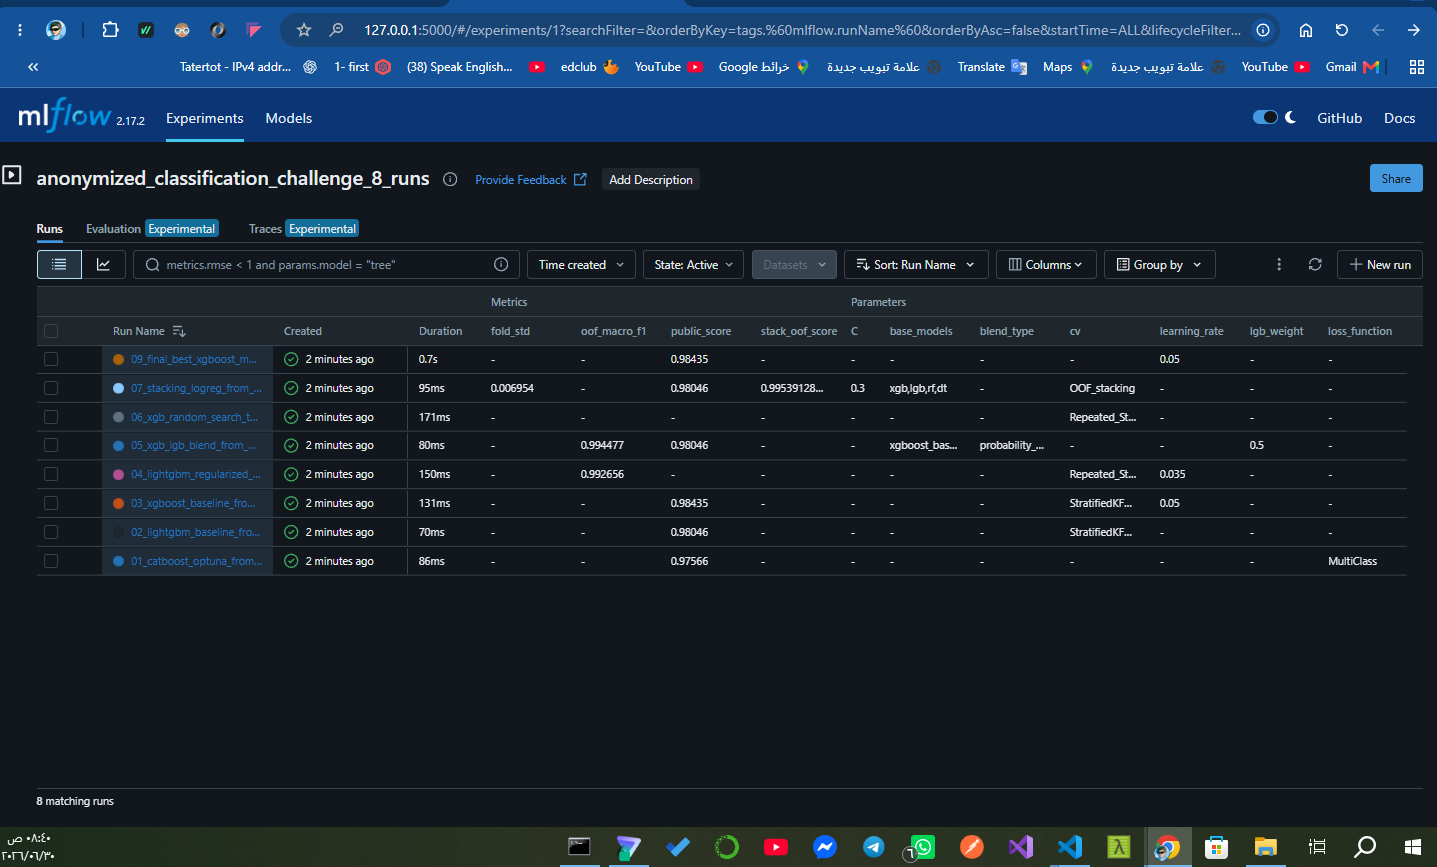

# ##########################################################################

# ##########################################################################

# ##########################################################################

# ##########################################################################

# DVC Data Version Controll

# https://github.com/Marwan-Ahmad/ForDVC

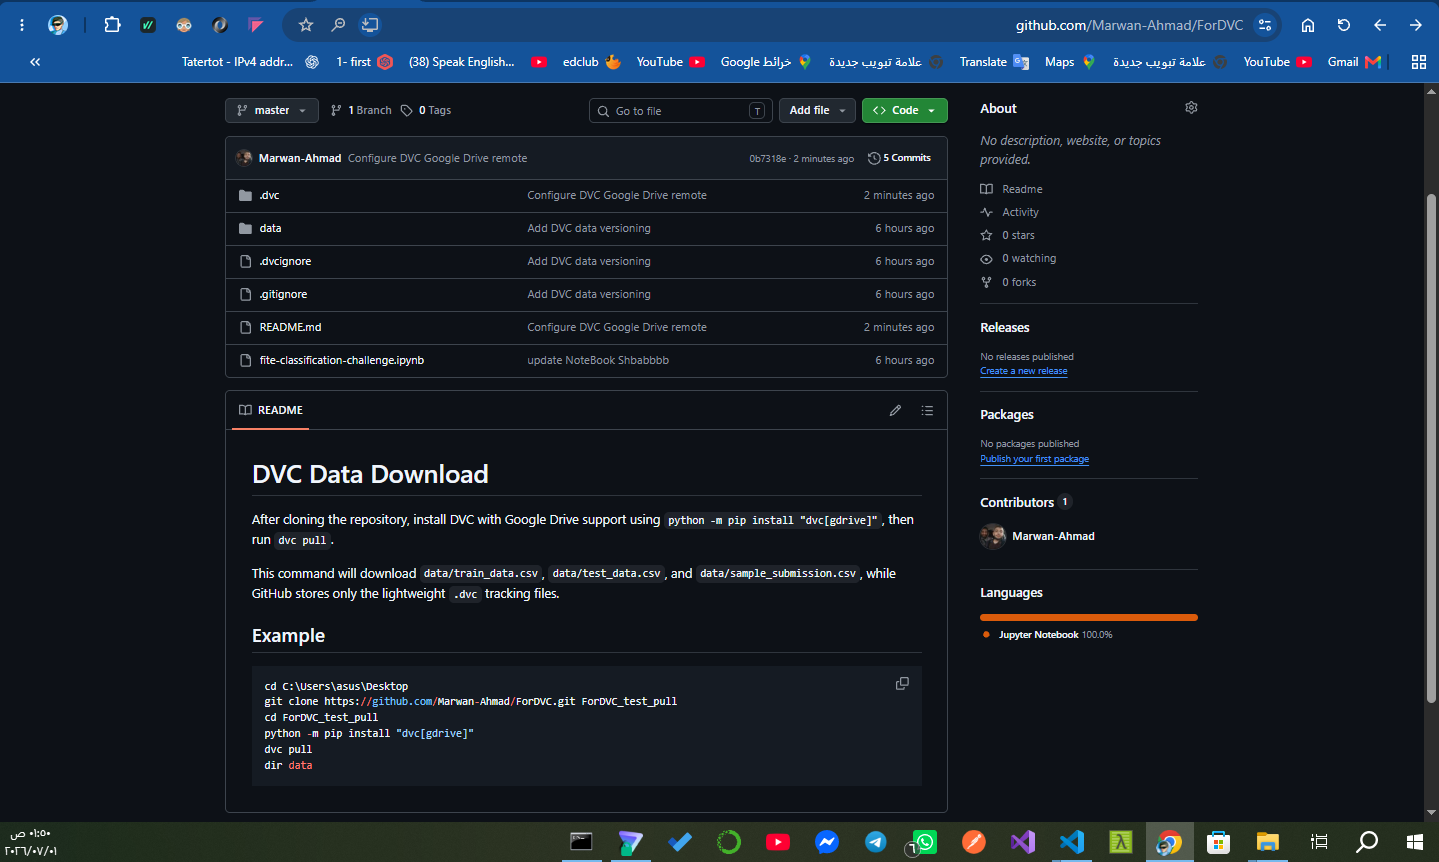

# ملف الداتا فية بس ملفات ال dvc 

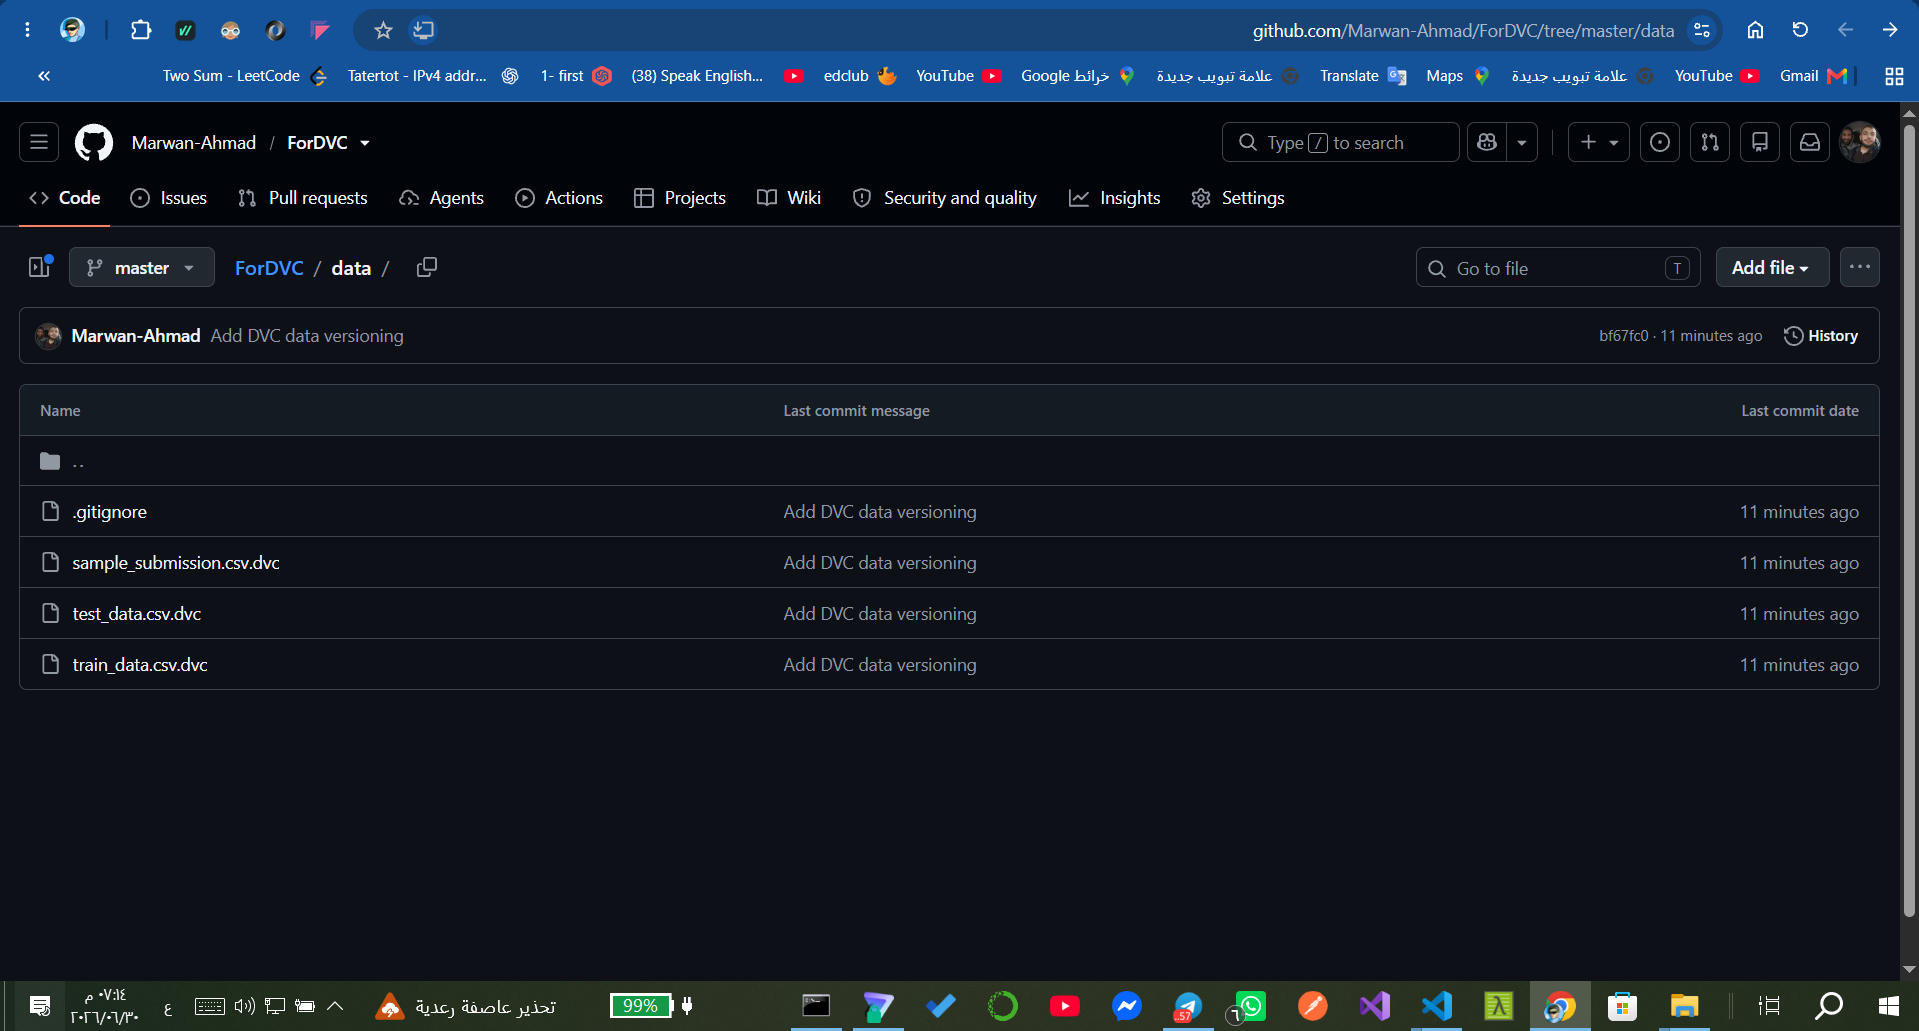

# ربطنا ملف ال dvc_remote_storage مع google Drive Api بحيث صار فيكم تعملو pull 

# مثال :

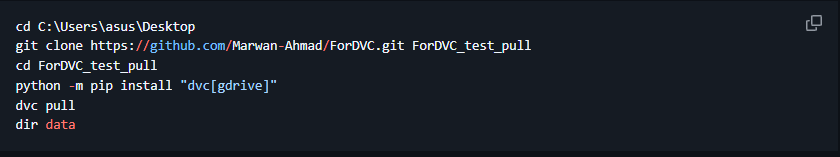